## Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import numpy as np
import time
import re
from pathlib import Path

## Funcões:

In [2]:
def calcular_media_steps(df, nc_value):
    """
    Função que calcula a média e o desvio padrão dos steps para um dado dataframe e um valor específico de NC.
    """
    mean_steps = df['steps'].mean()  # Supondo que a coluna dos passos seja 'steps'
    std_steps = df['steps'].std()    # Desvio padrão dos passos
    return nc_value, mean_steps, std_steps

def plotar_media_steps_com_erro(dfs_list, nc_values, labels, 
                                title, xlabel, ylabel, 
                                x_log=True, y_log=True, 
                                x_min=None, x_max=None, 
                                y_min=None, y_max=None,
                                save_path=None,
                                num_solid_lines=2):
    """
    Gera um gráfico de médias de steps com barras de erro para diferentes listas de dataframes organizadas por valores de 'O'.

    Parameters:
    - dfs_list: lista de listas de dataframes, onde cada sub-lista representa um valor de 'O'.
    - nc_values: lista com valores de NC correspondentes a cada sub-lista de dataframes.
    - labels: lista de rótulos para cada sub-lista de dataframes (valores de 'O').
    - title: título do gráfico.
    - xlabel: rótulo do eixo x.
    - ylabel: rótulo do eixo y.
    - x_log: define se o eixo x será em escala logarítmica (True por padrão).
    - y_log: define se o eixo y será em escala logarítmica (True por padrão).
    - x_min, x_max: limites inferior e superior para o eixo x.
    - y_min, y_max: limites inferior e superior para o eixo y.
    - save_path: caminho para salvar o gráfico (opcional).
    - num_solid_lines: número de linhas que serão plotadas como sólidas. As linhas subsequentes serão tracejadas.
    """

    plt.figure(figsize=(14, 8))

    for i, (dfs, nc_value, label) in enumerate(zip(dfs_list, nc_values, labels)):
        # Calcular as médias e desvios para cada dataframe na lista de dataframes específica
        nc_vals = []
        means = []
        std_devs = []
        
        for df, n in zip(dfs, nc_value):
            nc, mean, std = calcular_media_steps(df, n)
            nc_vals.append(nc)
            means.append(mean)
            std_devs.append(std)

        # Definir o estilo da linha com base no número de linhas já plotadas
        line_style = '-' if i < num_solid_lines else '--'

        # Gerar o gráfico com erro
        plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)

    if x_log:
        plt.xscale('log')
    if y_log:
        plt.yscale('log')

    # Definir os limites dos eixos, se fornecidos
    if x_min is not None and x_max is not None:
        plt.xlim(x_min, x_max)
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)

    # Colocar a legenda fora do gráfico e dividir em duas colunas
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., 
               ncol=2, prop={'size': 14})

    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.title(title, fontsize=18)
    plt.xlabel(xlabel, fontsize=18)
    plt.ylabel(ylabel, fontsize=18)
    plt.grid(True)

    # Ajustar o layout para evitar cortes na legenda
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')  # Garante que a legenda seja incluída ao salvar
        
    plt.show()

In [3]:
#gera o histograma unico
def gerar_histogramas_individuais_com_label(
    dfs, 
    labels, 
    nome_base, 
    titulo_base, 
    xlabel, 
    ylabel, 
    bins=30, 
    x_log=False, 
    y_log=False, 
    x_min=None, 
    x_max=None, 
    y_min=None, 
    y_max=None
):
    """
    Gera histogramas de frequência normalizada, criando uma figura separada para cada DataFrame,
    usando o label no nome do arquivo.

    Parâmetros:
    - dfs: Lista de DataFrames com as colunas 'steps' e 'run'.
    - labels: Lista de rótulos para identificar cada DataFrame.
    - nome_base: Base para o nome dos arquivos (ex: 'histograma').
    - titulo_base: Base para o título dos gráficos.
    - xlabel: Rótulo do eixo x.
    - ylabel: Rótulo do eixo y.
    - bins: Número de bins no histograma.
    - x_log: Configura o eixo x como logarítmico (True/False).
    - y_log: Configura o eixo y como logarítmico (True/False).
    - x_min, x_max: Limites para o eixo x.
    - y_min, y_max: Limites para o eixo y.
    """
    for df, label in zip(dfs, labels):
        # Calcular frequência normalizada
        frequencia = df['steps'].value_counts().sort_index()
        frequencia_normalizada = frequencia / df['run'].nunique()

        # Gerar bins (logarítmicos se necessário)
        if x_log:
            bins_log = np.logspace(np.log10(frequencia_normalizada.index.min()), 
                                   np.log10(frequencia_normalizada.index.max()), 
                                   bins)
        else:
            bins_log = bins

        # Criar o histograma
        plt.figure(figsize=(8, 6))
        plt.hist(
            frequencia_normalizada.index,
            weights=frequencia_normalizada,
            bins=bins_log,
            alpha=0.7,
            edgecolor='black',
            label=label
        )

        # Configurar escala dos eixos
        if x_log:
            plt.xscale('log')
        if y_log:
            plt.yscale('log')

        # Adicionar rótulos e título
        plt.xlabel(xlabel, fontsize=16)
        plt.ylabel(ylabel, fontsize=16)
        plt.title(f"{titulo_base}", fontsize=18)

        # Configurar limites dos eixos
        if x_min is not None and x_max is not None:
            plt.xlim(x_min, x_max)
        if y_min is not None and y_max is not None:
            plt.ylim(y_min, y_max)

        # Configurar os ticks
        plt.tick_params(axis='both', which='major', labelsize=14)

        # Adicionar legenda
        plt.legend(fontsize=12)

        # Substituir caracteres inválidos por '_'
        label_safe = re.sub(r'[^\w\_\.]', '_', label)

        # Remover underscores consecutivos
        label_safe = re.sub(r'_+', '_', label_safe)

        # Remover partes específicas indesejadas como "N_E" e "NE"
        label_safe = re.sub(r'\bN_{E}\b|\bNE\b', '', label_safe)

        # Remover underscores extras no início e no final
        label_safe = label_safe.strip('_')

        # Construir o nome do arquivo sem underscores extras e partes indesejadas
        nome_arquivo = f"{nome_base}{label_safe}.png"

        # Salvar o gráfico
        plt.savefig(nome_arquivo)

        # Mostrar o gráfico
        plt.show()

In [4]:
# gera os histogramas juntos.
def gerar_histogramas_normalizados(
    dfs1, 
    dfs2, 
    labels1,
    labels2,
    nome_base, 
    titulo_base, 
    xlabel, 
    ylabel, 
    bins=30, 
    x_log=False, 
    y_log=False, 
    x_min=None, 
    x_max=None, 
    y_min=None, 
    y_max=None
):
    """
    Gera gráficos individuais comparando histogramas normalizados de dois conjuntos de DataFrames.
    
    Cada gráfico conterá dois histogramas sobrepostos no mesmo gráfico, permitindo definir rótulos individuais para cada um.

    Parâmetros:
    - dfs1: Lista de DataFrames do primeiro conjunto, com as colunas 'steps' e 'run'.
    - dfs2: Lista de DataFrames do segundo conjunto, com as colunas 'steps' e 'run'.
    - labels1: Lista de rótulos para identificar os DataFrames do primeiro conjunto.
    - labels2: Lista de rótulos para identificar os DataFrames do segundo conjunto.
    - nome_base: Base para o nome dos arquivos (ex: 'histograma').
    - titulo_base: Base para o título dos gráficos.
    - xlabel: Rótulo do eixo x.
    - ylabel: Rótulo do eixo y.
    - bins: Número de bins no histograma.
    - x_log: Configura o eixo x como logarítmico (True/False).
    - y_log: Configura o eixo y como logarítmico (True/False).
    - x_min, x_max: Limites para o eixo x.
    - y_min, y_max: Limites para o eixo y.
    """
    for df1, df2, label1, label2 in zip(dfs1, dfs2, labels1, labels2):
        plt.figure(figsize=(8, 6))
        
        for df, label, color in zip([df1, df2], [label1, label2], ['blue', 'red']):
            # Calcular frequência normalizada
            frequencia = df['steps'].value_counts().sort_index()
            frequencia_normalizada = frequencia / frequencia.sum()

            # Gerar bins (logarítmicos se necessário)
            if x_log:
                bins_log = np.logspace(np.log10(frequencia.index.min()), 
                                       np.log10(frequencia.index.max()), 
                                       bins)
            else:
                bins_log = bins

            # Adicionar histograma ao gráfico
            plt.hist(
                frequencia_normalizada.index,
                weights=frequencia_normalizada,
                bins=bins_log,
                alpha=0.5,
                edgecolor='black',
                color=color,
                label=label,
                density=True  # Normalização dos histogramas
            )

        # Configurar escala dos eixos
        if x_log:
            plt.xscale('log')
        if y_log:
            plt.yscale('log')

        # Adicionar rótulos e título
        plt.xlabel(xlabel, fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        plt.title(f"{titulo_base}", fontsize=16)

        # Configurar escala dos eixos
        if x_log:
            plt.xscale('log')
        if y_log:
            plt.yscale('log')

        # Adicionar rótulos e título
        plt.xlabel(xlabel, fontsize=14)
        plt.ylabel(ylabel, fontsize=14)
        plt.title(f"{titulo_base}", fontsize=16)

        # Configurar limites dos eixos
        if x_min is not None and x_max is not None:
            plt.xlim(x_min, x_max)
        if y_min is not None and y_max is not None:
            plt.ylim(y_min, y_max)

        # Adicionar legenda
        plt.legend(fontsize=12)
        
        # Construir nome do arquivo
        label_safe1 = re.sub(r'_+', '_', re.sub(r'[^\w\_\.]', '_', label1)).strip('_')
        label_safe2 = re.sub(r'_+', '_', re.sub(r'[^\w\_\.]', '_', label2)).strip('_')
        nome_arquivo = f"{nome_base}_{label_safe1}_vs_{label_safe2}.png"
        
        # Salvar e exibir o gráfico
        plt.savefig(nome_arquivo)
        plt.show()


## Dados

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [5]:
# O = 00
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_5"
df_NP01_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/"NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_5.dat", delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 2
df_NP01_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_5.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [6]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_10"
df_NP01_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_10.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [7]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_20.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [8]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_30.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [9]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 2s
df_NP01_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_40.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.95.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [10]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_095" / "Distribuição_quadrada"/ "SR_50"
# O = 0
df_NP01_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 02
df_NP01_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O =6
df_NP01_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 2
df_NP01_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.95_SR_50.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [11]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_5.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [12]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
#O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_10.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [13]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_20.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [14]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_30.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [15]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_40.dat', delimiter=',')

### TCC = 0.95 e TCT = 0.05.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [16]:
base_path = Path.home() / "Dados_Doc" / "TCC_095" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.95_TCT_0.05_SR_50.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [17]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_5.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [18]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_10"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_10.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [19]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_20.dat', delimiter=',')


### TCC = 0.05 e TCT = 0.05.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [20]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP01_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# # O = 21
df_NP01_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

df_NP01_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_30.dat', delimiter=',')


### TCC = 0.05 e TCT = 0.05.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [21]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_40"
df_NP01_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')


# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 2s
df_NP01_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_40.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.05.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [22]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_005" / "Distribuição_quadrada"/ "SR_50"
# O = 0
df_NP01_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 02
df_NP01_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 3
df_NP01_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 5
df_NP01_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O =6
df_NP01_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 11
df_NP01_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# # O = 2
df_NP01_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

# O = 51
df_NP01_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv (base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.05_SR_50.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 5.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [23]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_5"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_5.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 10.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [24]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_10"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_10.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 20.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [25]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_20"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_20.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 30.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [26]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_30"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_30.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 40.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [27]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_40"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_40.dat', delimiter=',')

### TCC = 0.05 e TCT = 0.95.
- Raio de procura 50.
- NC = 500.
- NE = 1, 2, 5, 10, 20,30,40,50,60,70,80,90 100, 500, 1000.

In [28]:
base_path = Path.home() / "Dados_Doc" / "TCC_005" / "TCT_095" / "Distribuição_quadrada"/ "SR_50"
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_0_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 00
df_NP01_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_2_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 3
df_NP01_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_3_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 5
df_NP01_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_5_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 6
df_NP01_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_6_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 11
df_NP01_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_11_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 21
df_NP01_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_21_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# # O = 26
df_NP01_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_26_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
# O = 51
df_NP01_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP02_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_2_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP05_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_5_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP10_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_10_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP20_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_20_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP30_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_30_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP40_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_40_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP50_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_50_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP60_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_60_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP70_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_70_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP80_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_80_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP90_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_90_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP100_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_100_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP500_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_500_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')
df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50 = pd.read_csv(base_path/'NC_500_NE_1000_O_51_TCC_0.05_TCT_0.95_SR_50.dat', delimiter=',')

# Resultados

## Trapping time

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 1.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


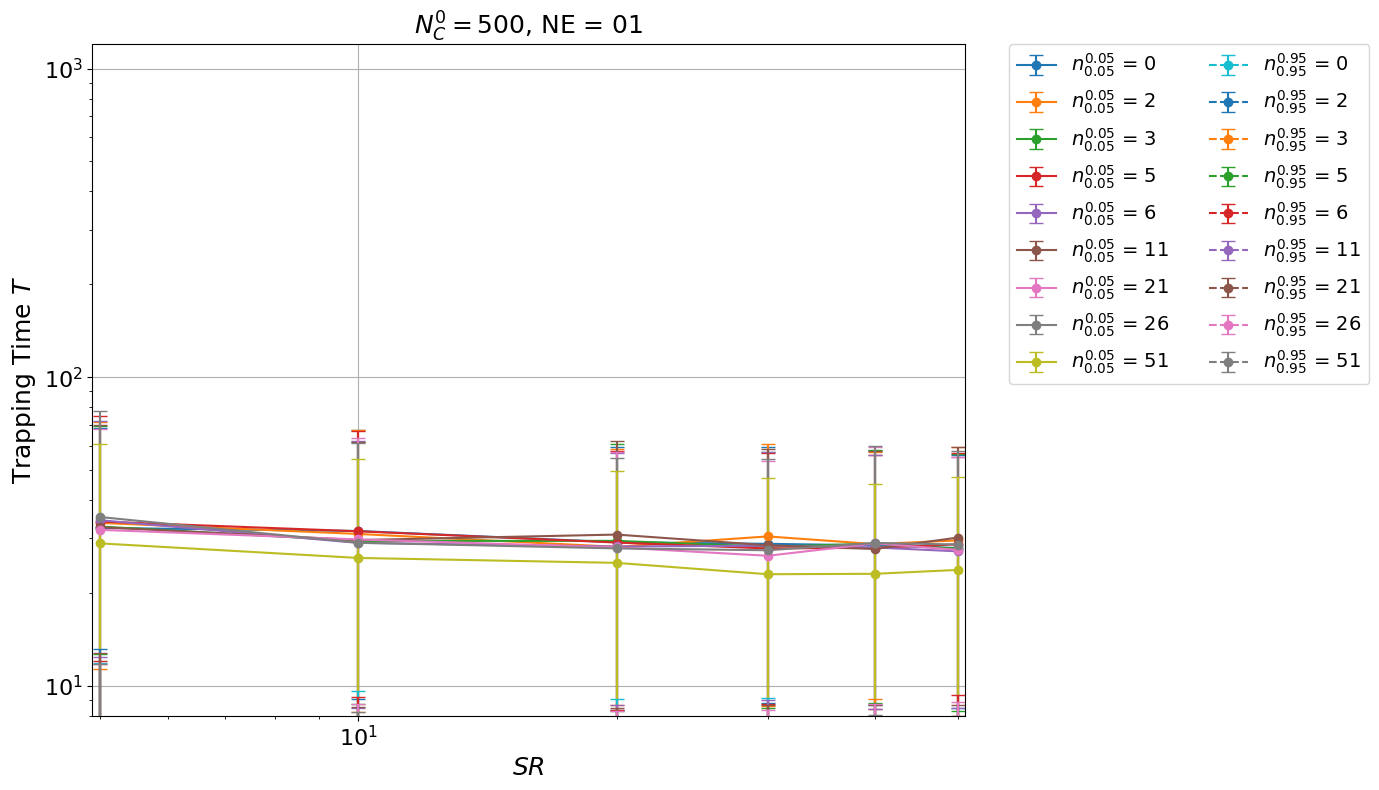

In [29]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP01_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP01_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP01_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP01_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP01_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP01_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP01_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP01_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP01_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP01_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP01_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP01_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP01_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 01", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_1_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 2.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


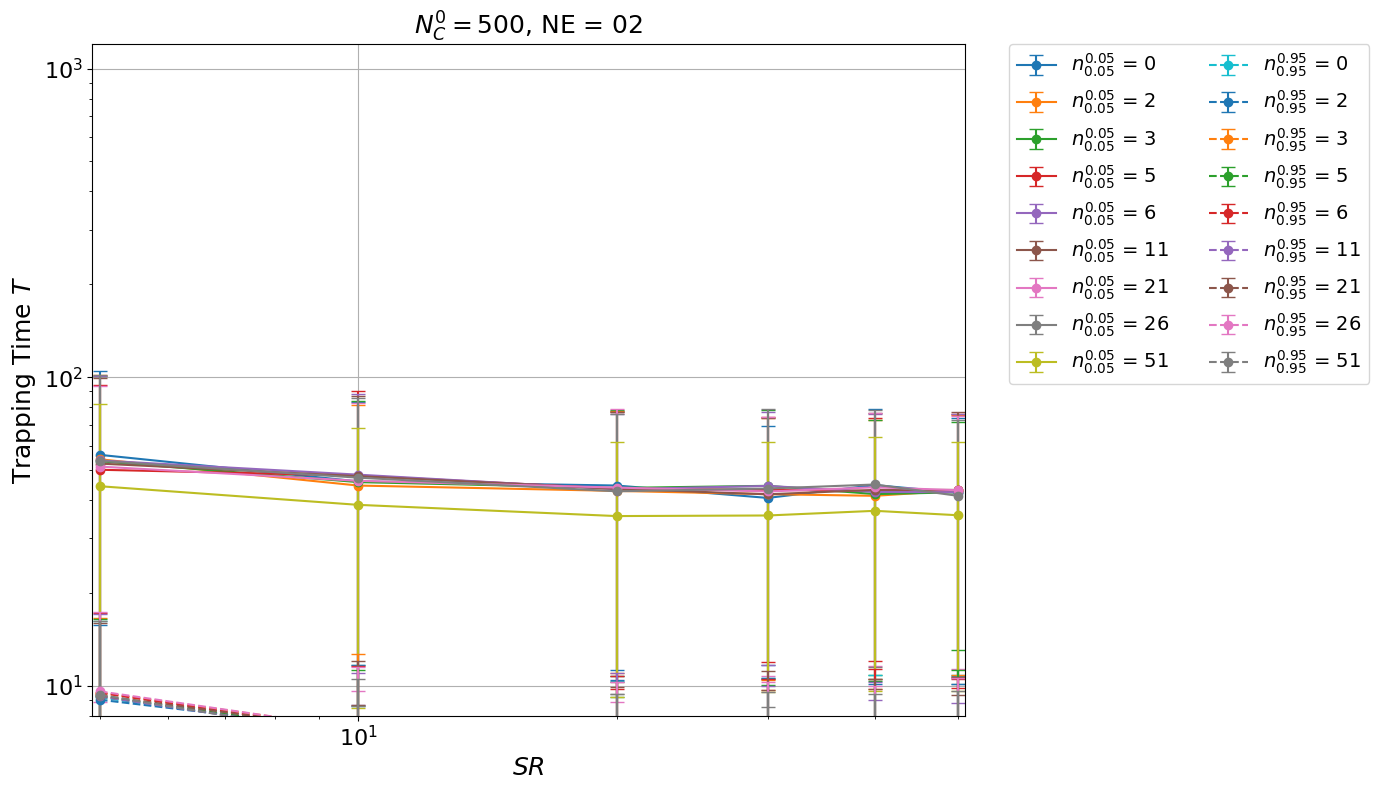

In [30]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP02_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP02_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP02_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP02_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP02_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP02_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP02_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP02_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP02_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP02_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP02_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP02_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP02_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP02_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP02_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 02", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_2_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 5.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


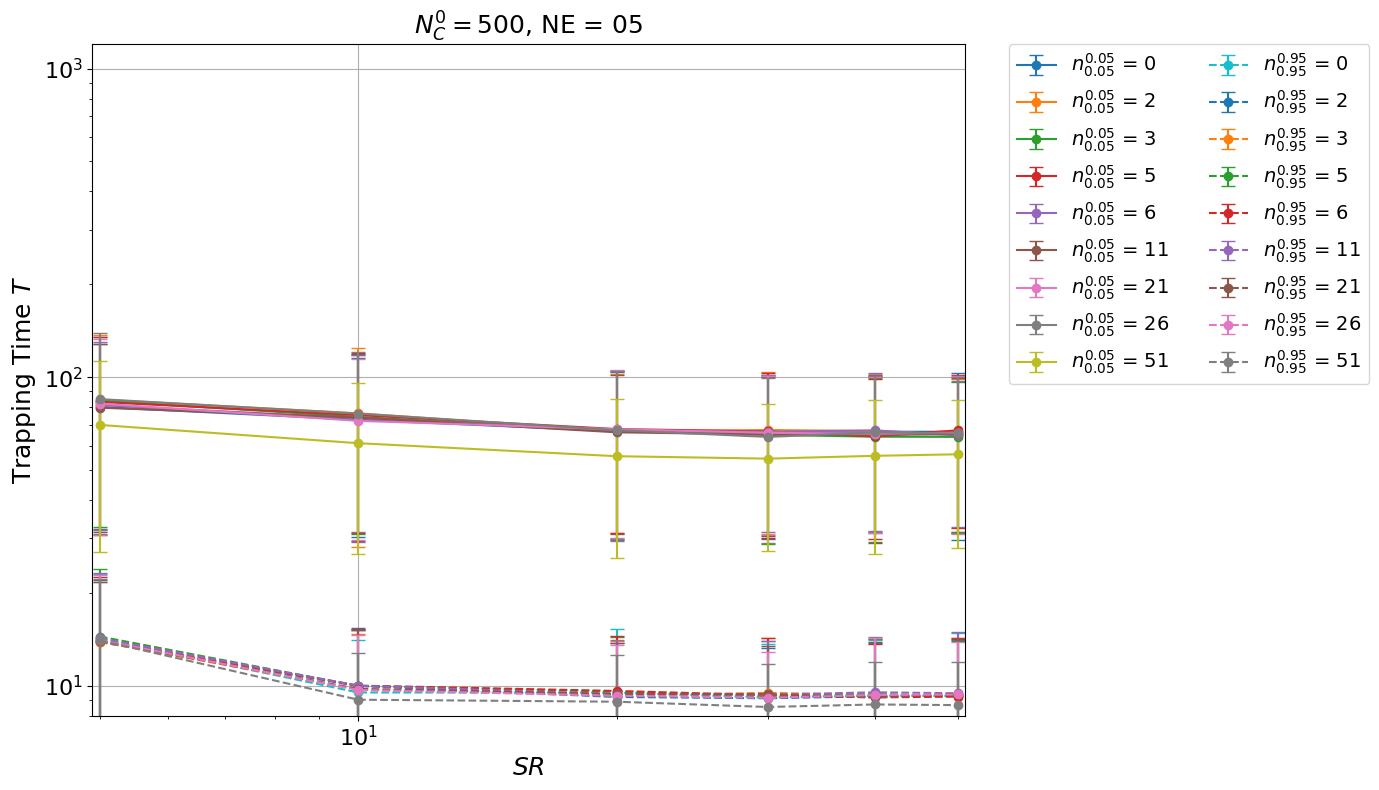

In [31]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP05_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP05_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP05_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP05_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP05_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP05_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP05_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP05_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP05_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP05_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP05_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP05_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP05_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP05_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP05_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 05", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_5_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 10.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


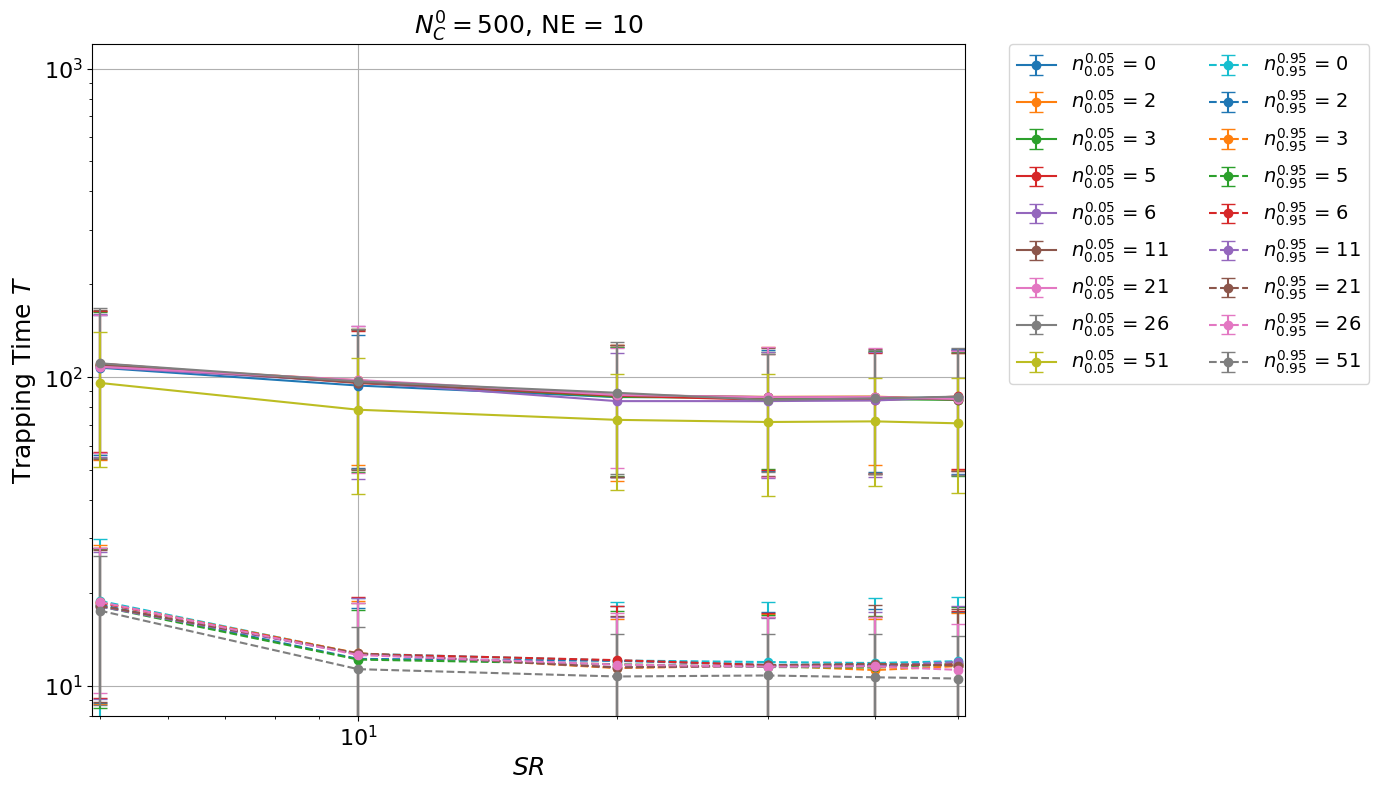

In [32]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 10", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200,
    save_path="trap_x_SR_TCC_both_TCT_both_NE_10_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 20.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


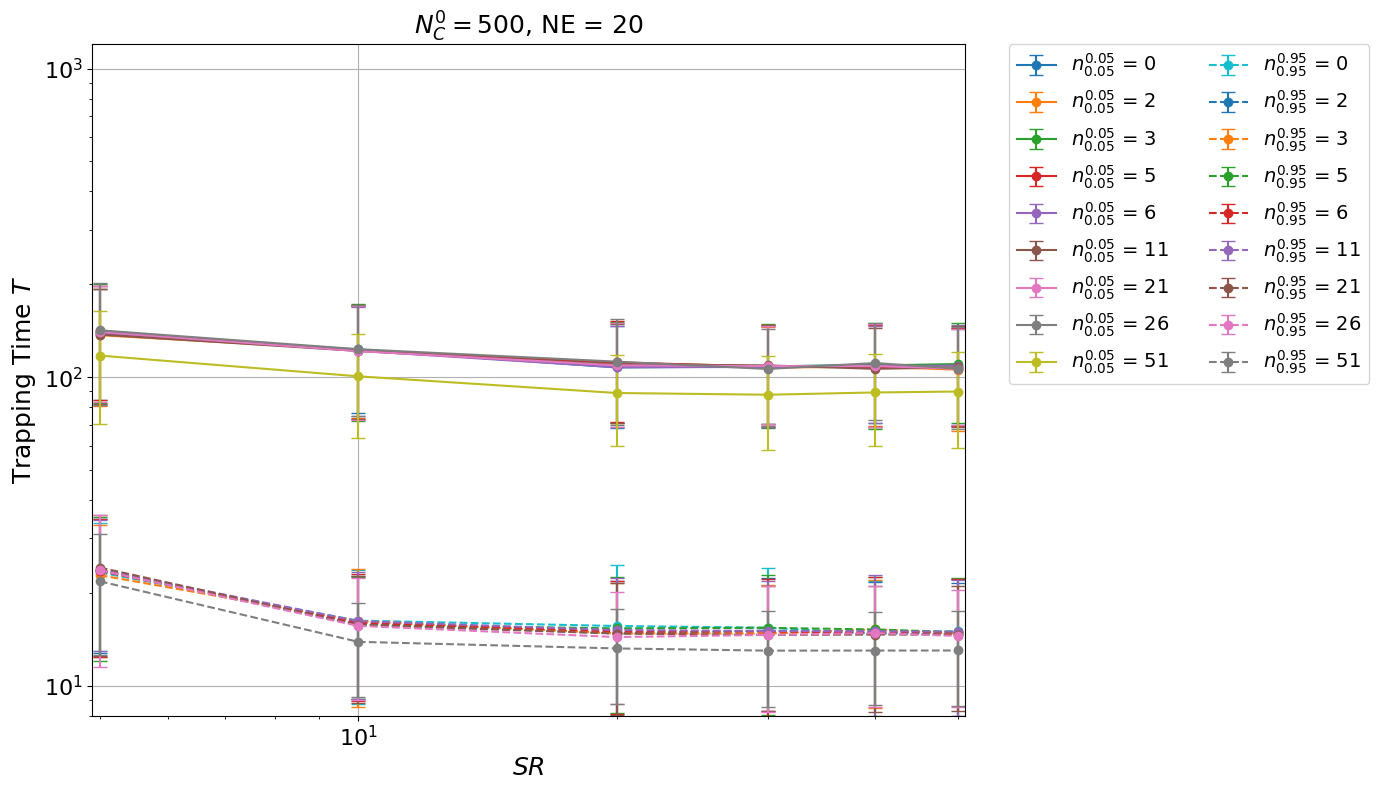

In [33]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP20_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP20_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP20_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP20_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP20_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP20_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP20_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP20_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 20", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_20_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 30.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


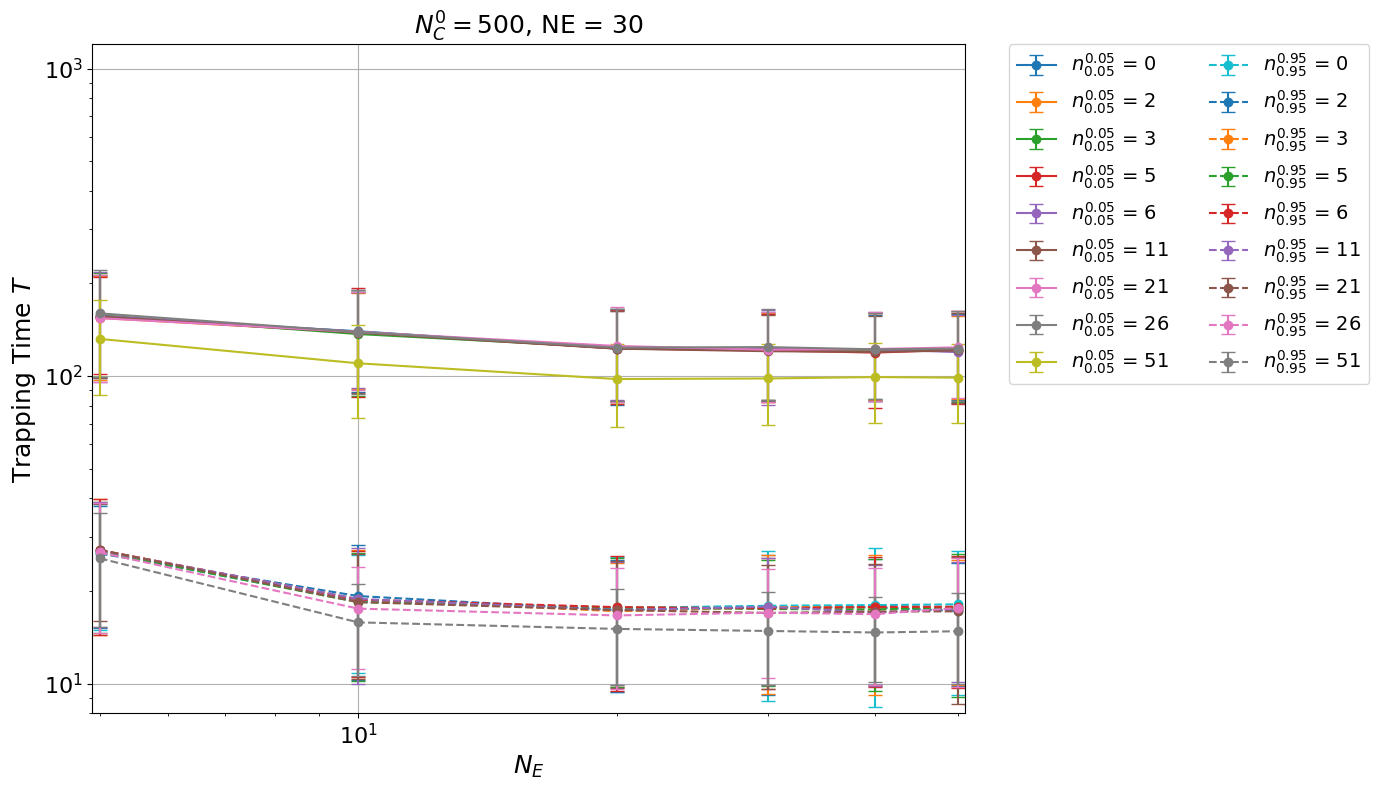

In [34]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP30_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP30_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP30_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP30_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP30_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP30_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP30_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP30_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP30_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP30_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP30_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP30_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP30_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP30_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP30_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 30", 
    xlabel="$N_{E}$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200,
    save_path="trap_x_SR_TCC_both_TCT_both_NE_30_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 40.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


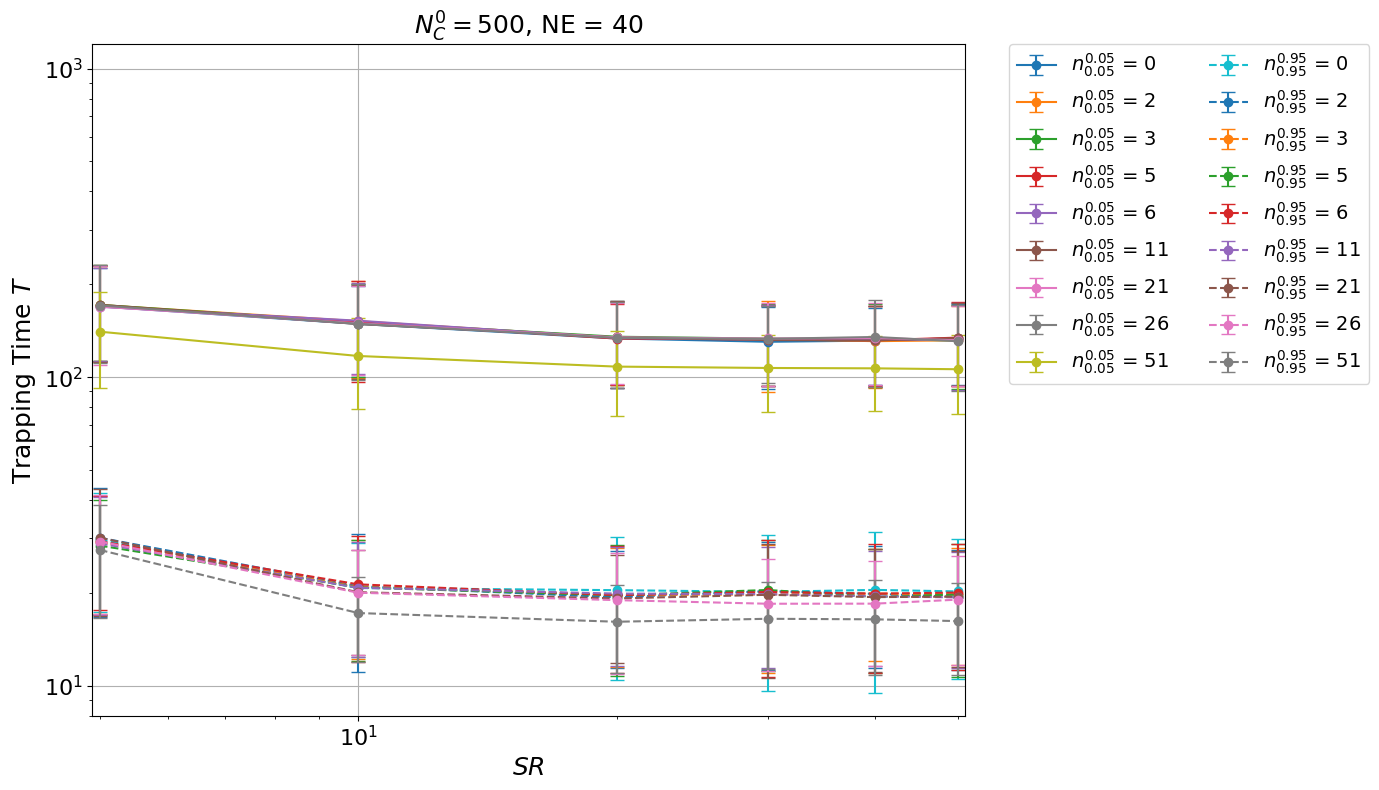

In [35]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]
plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 40", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_40_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95 
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 50.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


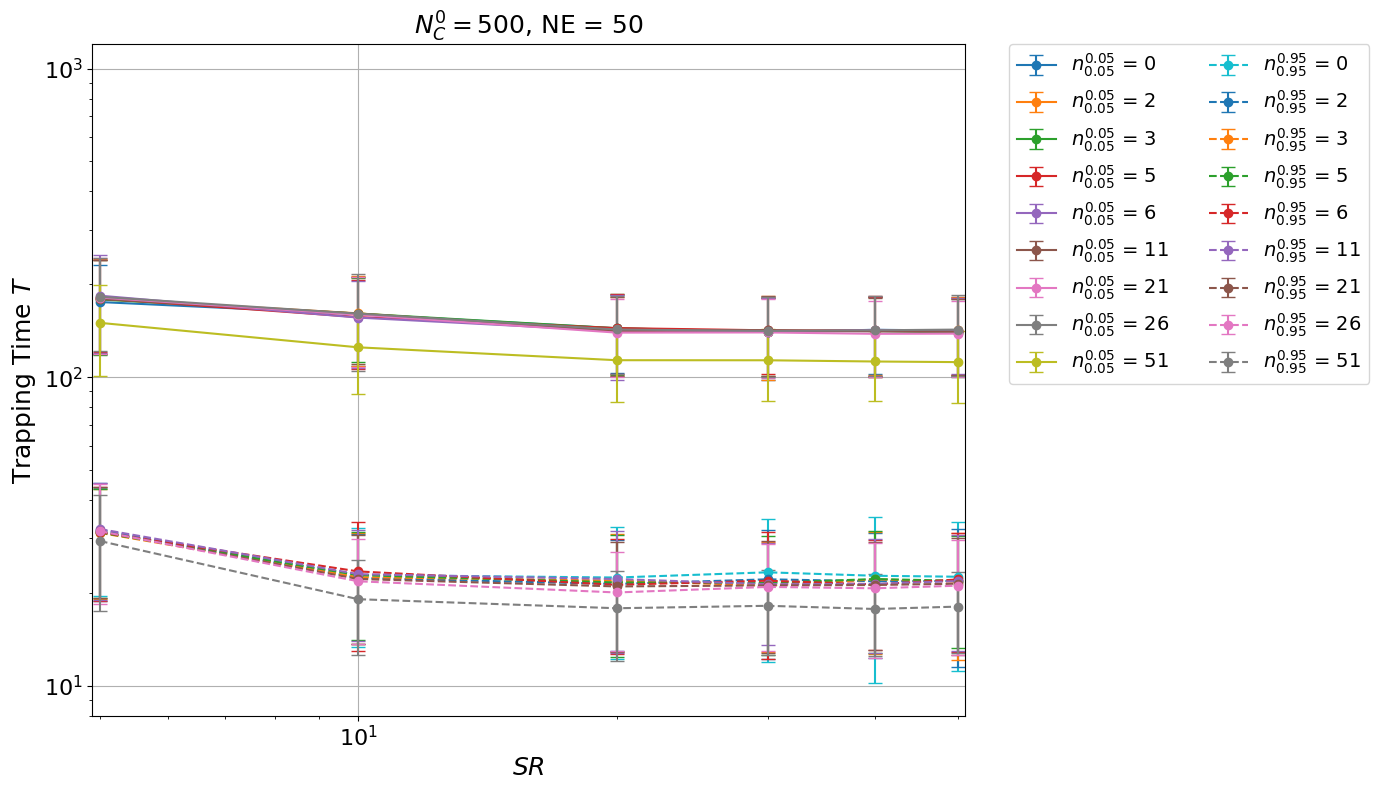

In [36]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP50_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP50_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP50_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP50_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP50_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP50_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP50_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP50_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP50_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP50_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP50_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP50_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP50_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP50_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP50_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 50", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200,
    save_path="trap_x_SR_TCC_both_TCT_both_NE_50_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 60.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


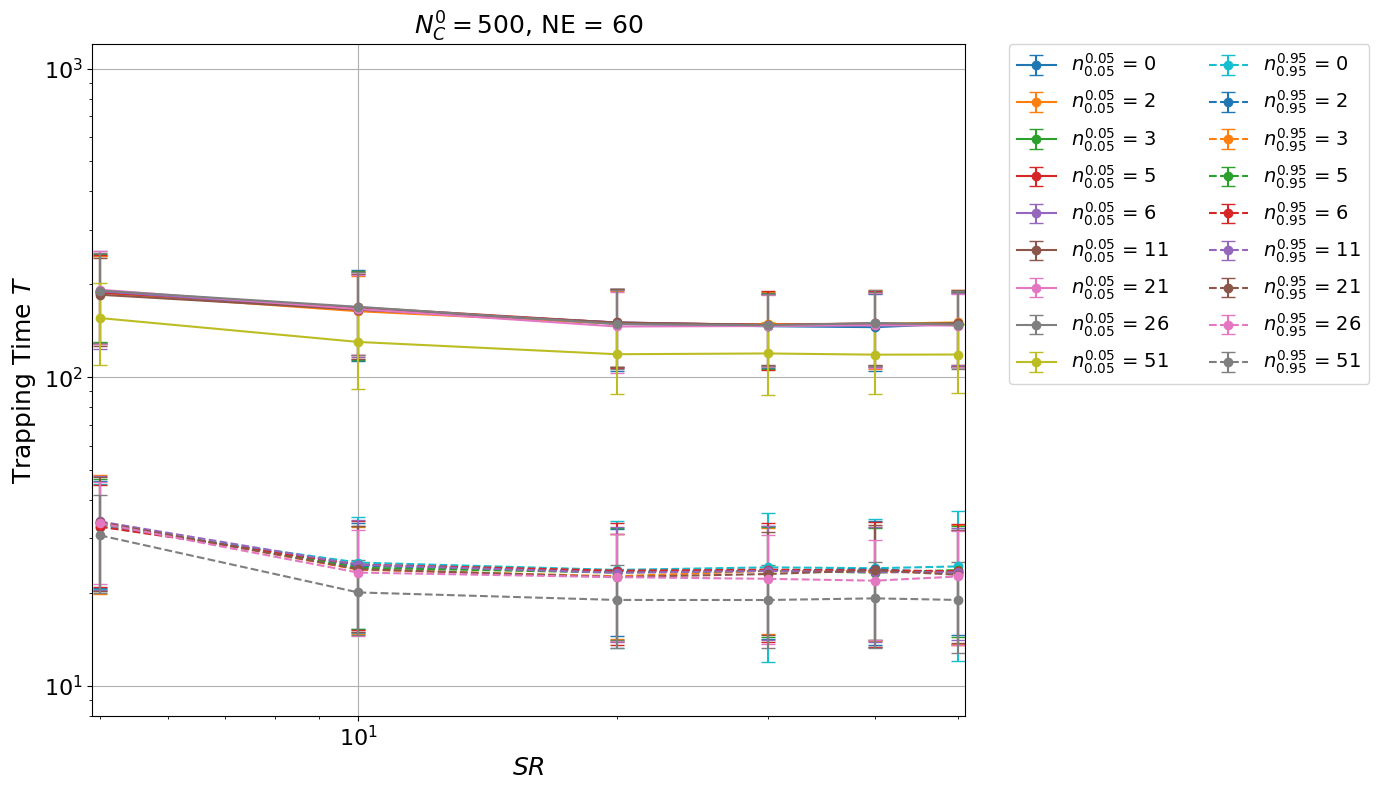

In [37]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP60_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP60_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP60_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP60_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP60_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP60_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP60_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP60_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP60_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP60_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP60_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP60_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP60_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP60_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP60_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 60", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200,
    save_path="trap_x_SR_TCC_both_TCT_both_NE_60_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 1.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


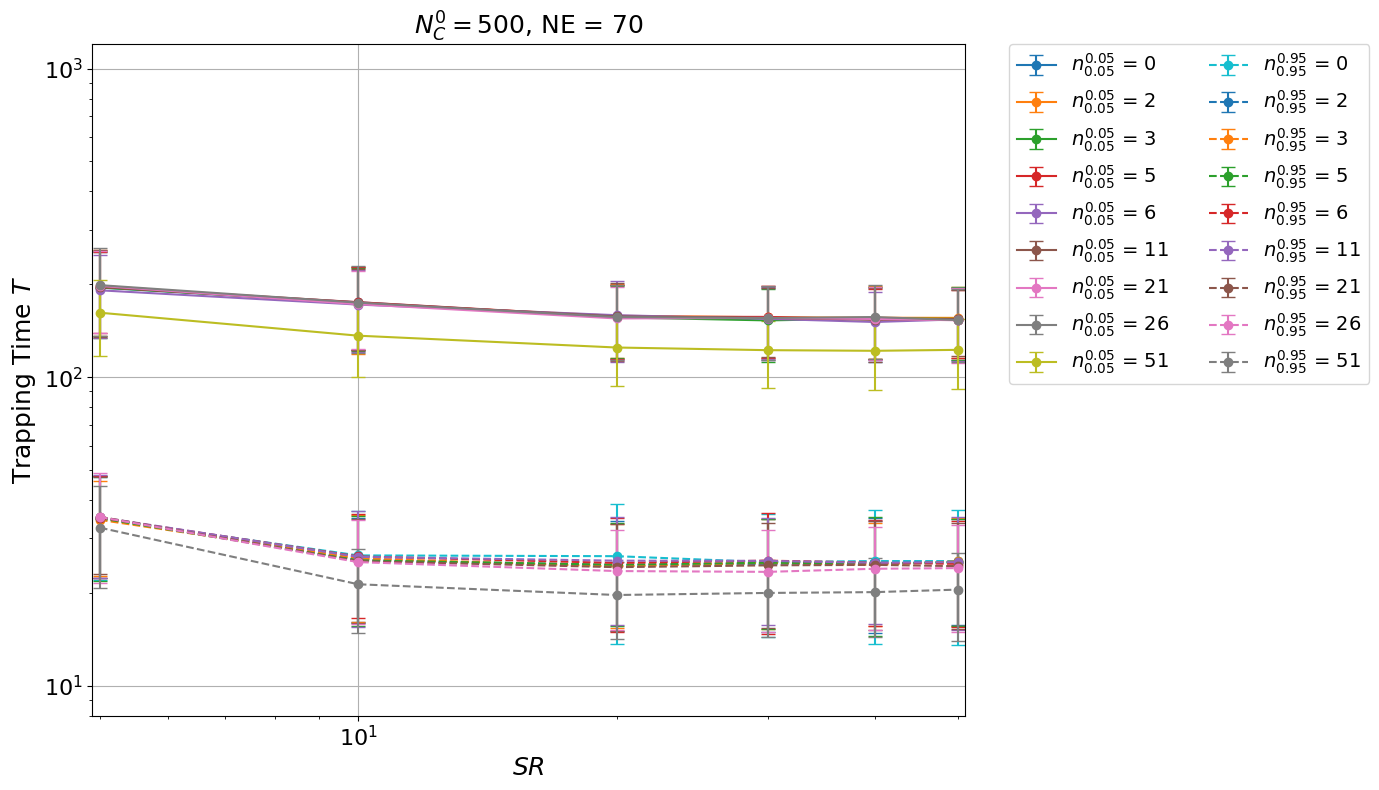

In [38]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP70_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP70_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP70_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP70_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP70_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP70_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP70_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP70_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP70_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP70_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP70_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP70_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP70_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP70_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP70_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 70", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_70_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 80.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


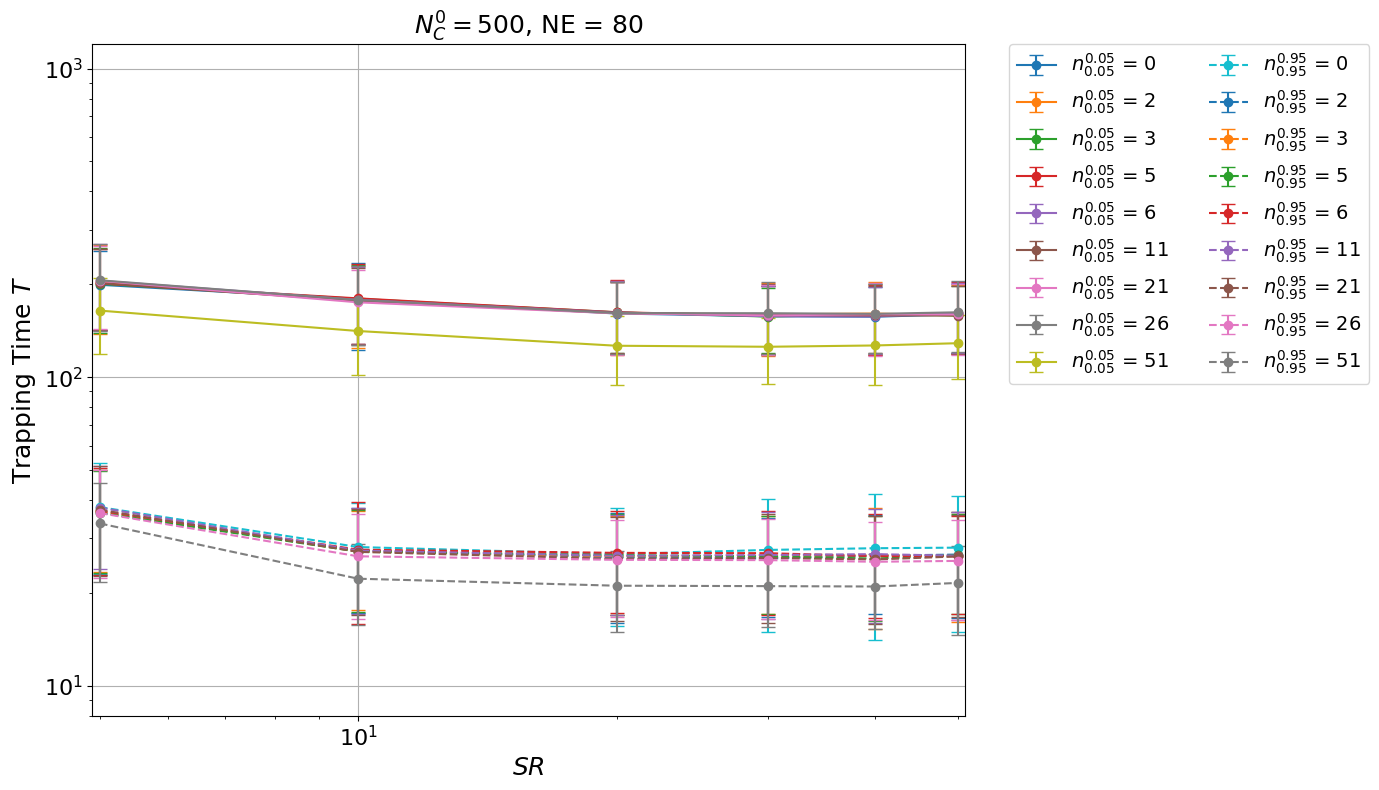

In [39]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP80_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP80_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP80_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP80_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP80_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP80_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP80_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP80_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP80_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP80_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP80_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP80_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP80_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP80_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP80_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 80", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_80_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 90.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


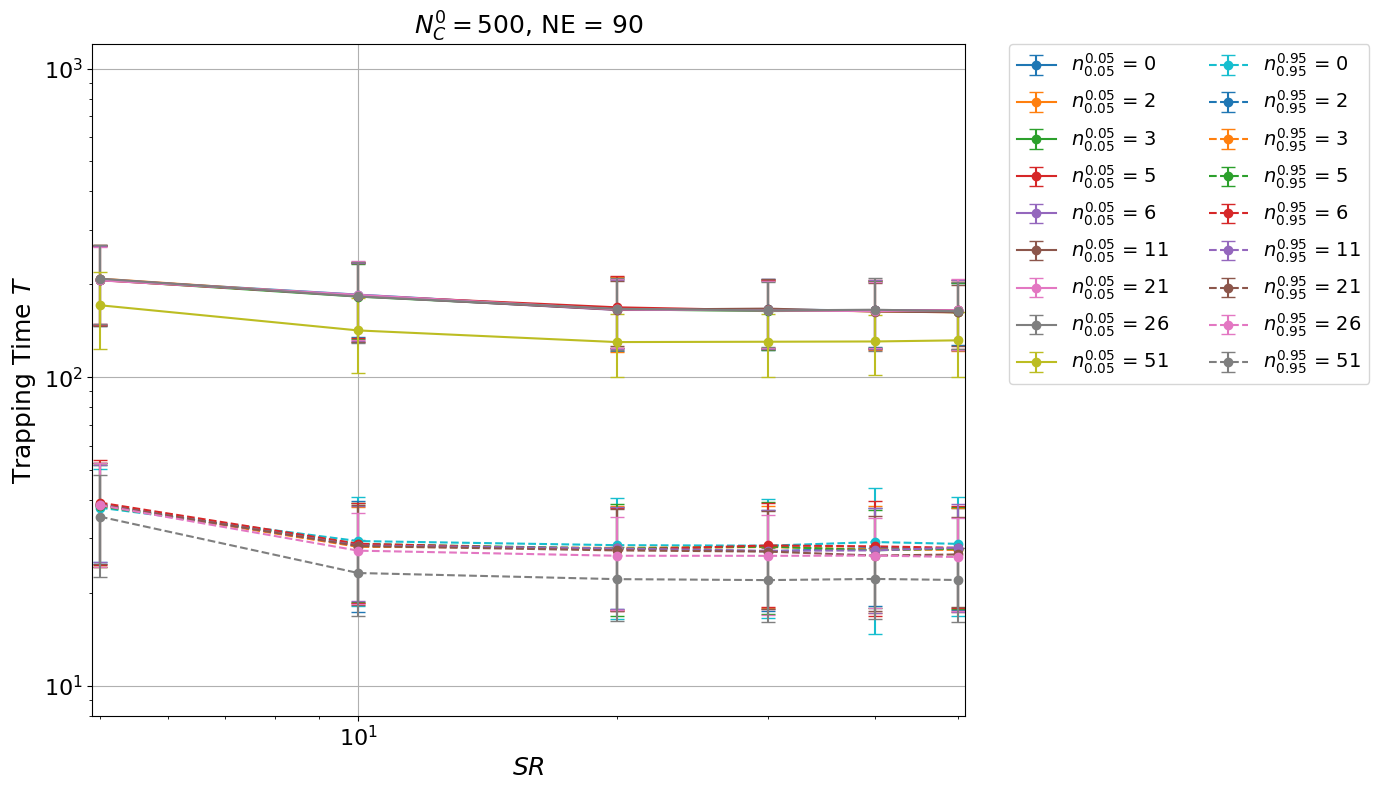

In [40]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP90_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP90_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP90_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP90_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP90_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP90_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP90_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP90_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP90_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP90_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP90_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP90_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP90_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP90_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP90_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 90", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_90_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 100.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


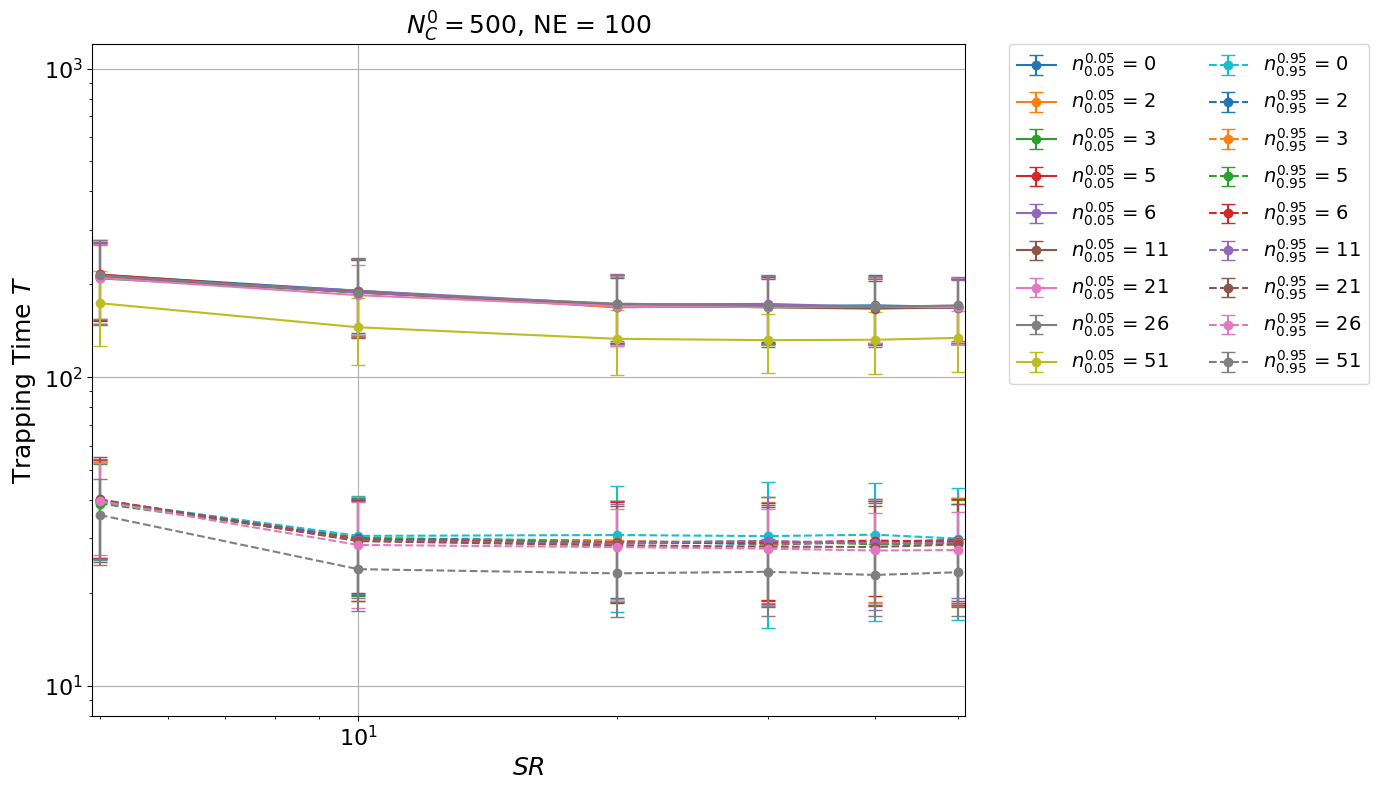

In [41]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP100_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP100_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP100_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP100_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP100_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP100_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP100_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP100_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP100_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP100_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP100_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP100_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP100_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP100_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP100_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 100", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_100_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 500.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


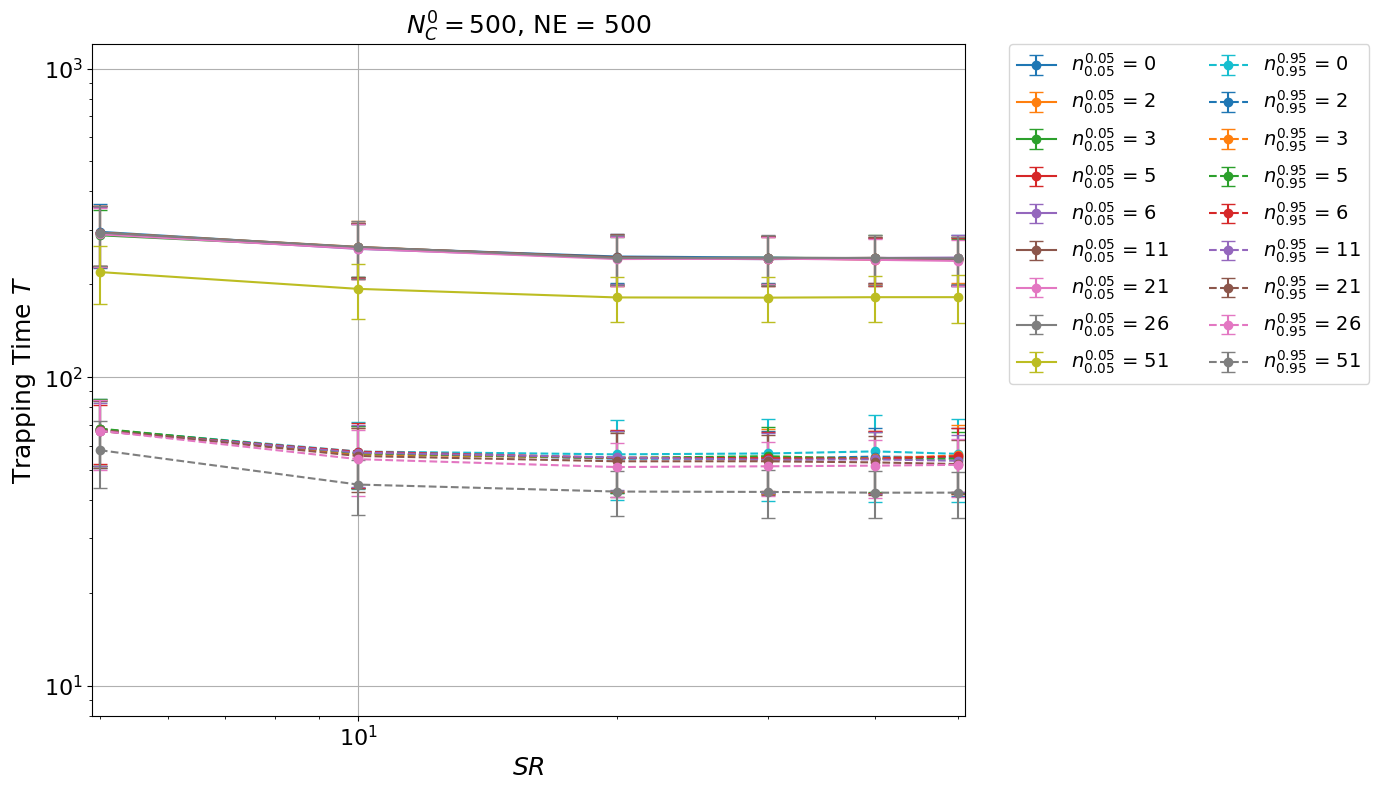

In [42]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP500_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP500_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP500_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP500_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP500_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP500_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP500_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP500_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 500", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_both_TCT_both_NE_500_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.05. e TCC = 0.95 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 1000.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


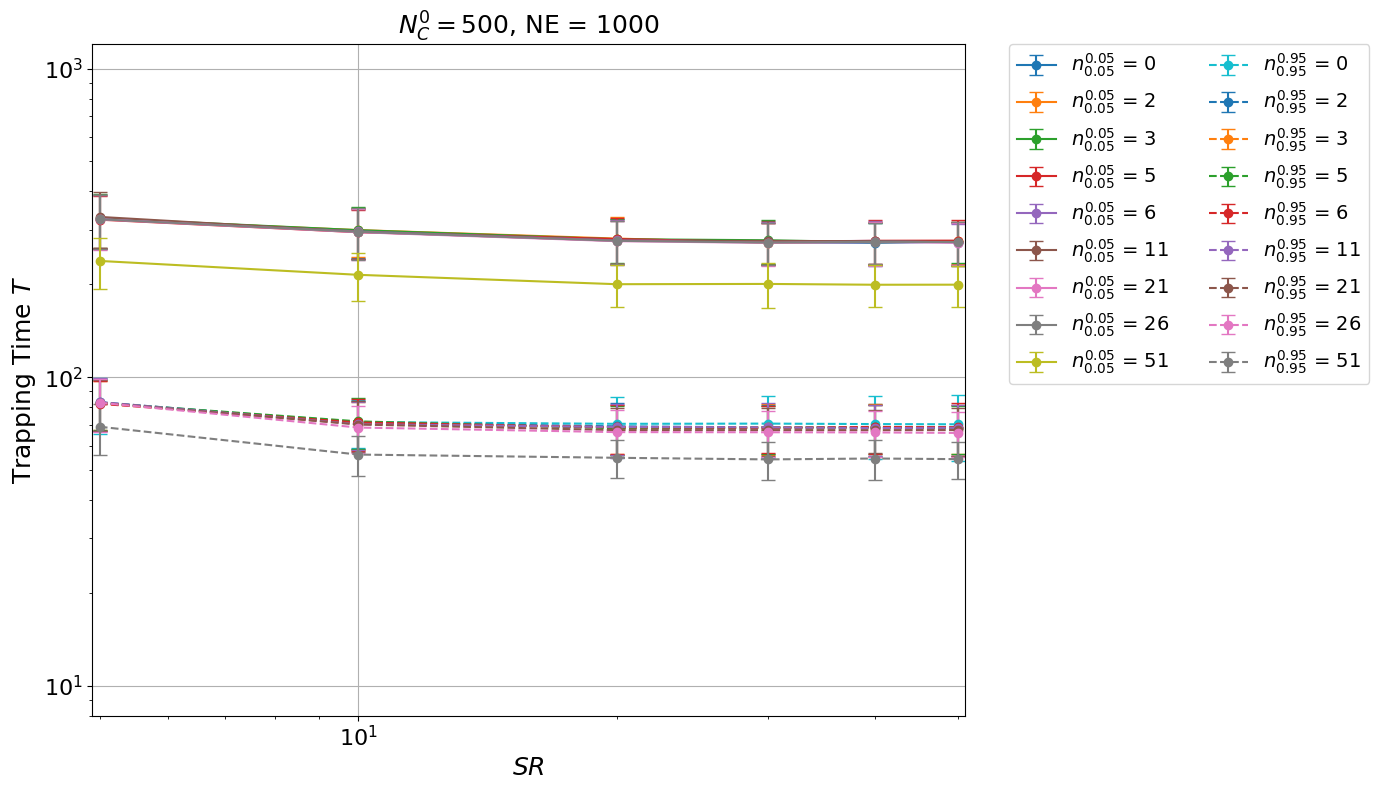

In [43]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP1000_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP1000_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP1000_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP1000_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP1000_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    # Bloco para O_01
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP1000_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP1000_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP1000_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP1000_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP1000_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.05}$ = 0", "$n_{0.05}^{0.05}$ = 2", "$n_{0.05}^{0.05}$ = 3", "$n_{0.05}^{0.05}$ = 5",
        "$n_{0.05}^{0.05}$ = 6", "$n_{0.05}^{0.05}$ = 11", "$n_{0.05}^{0.05}$ = 21",
        "$n_{0.05}^{0.05}$ = 26","$n_{0.05}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.95}$ = 0", "$n_{0.95}^{0.95}$ = 2", "$n_{0.95}^{0.95}$ = 3", "$n_{0.95}^{0.95}$ = 5", 
        "$n_{0.95}^{0.95}$ = 6", "$n_{0.95}^{0.95}$ = 11","$n_{0.95}^{0.95}$ = 21",
        "$n_{0.95}^{0.95}$ = 26","$n_{0.95}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 1000", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200,
    save_path="trap_x_SR_TCC_both_TCT_both_NE_1000_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 1.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


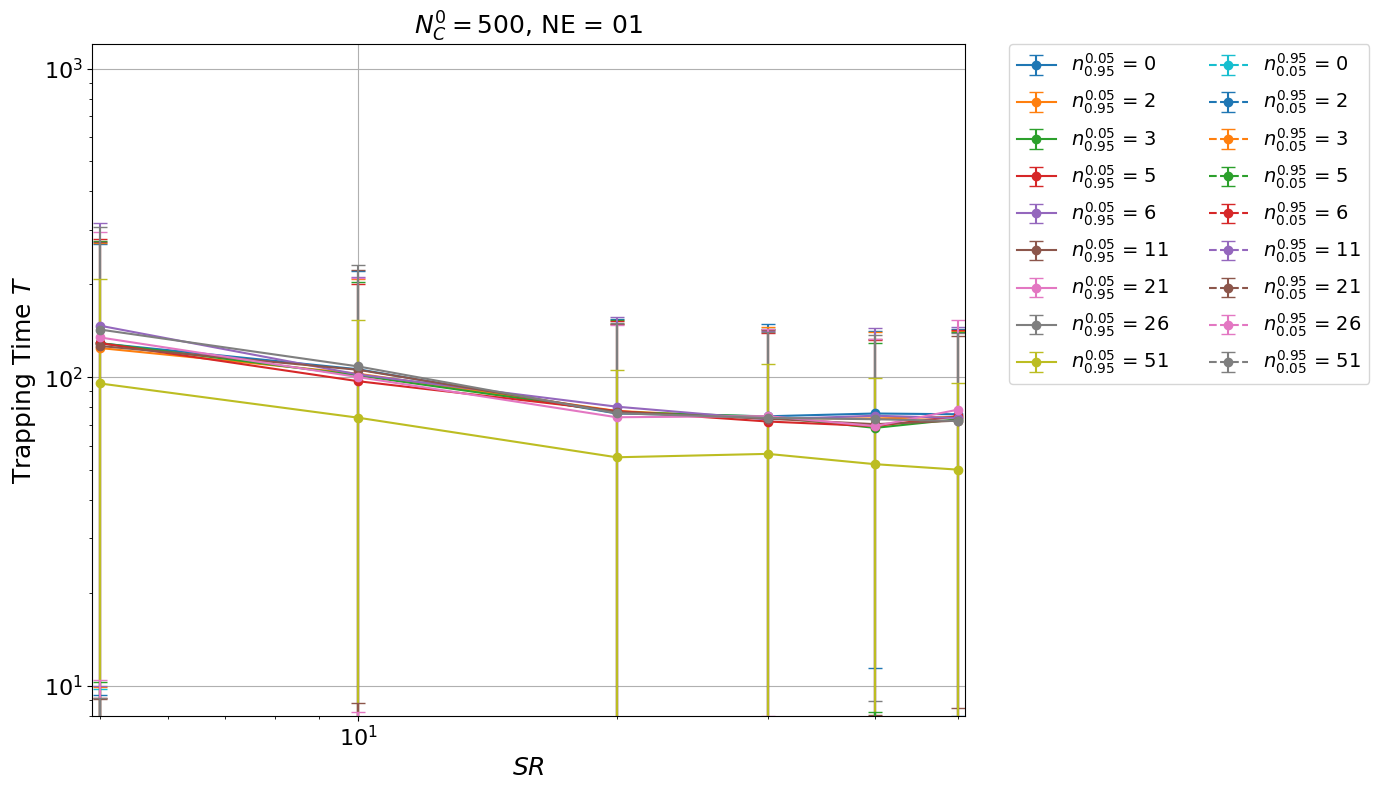

In [44]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 01", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_1_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 2.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


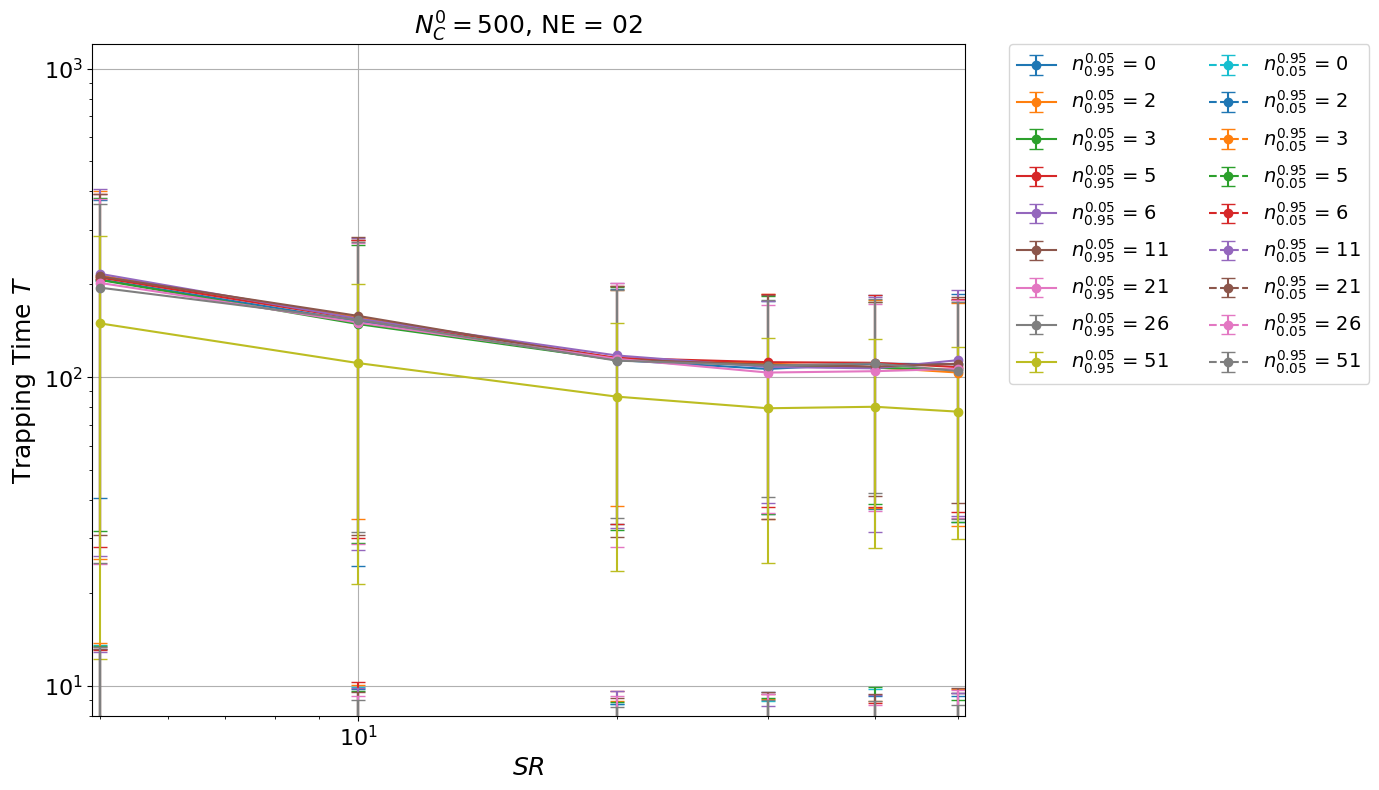

In [45]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 02", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_2_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 5.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


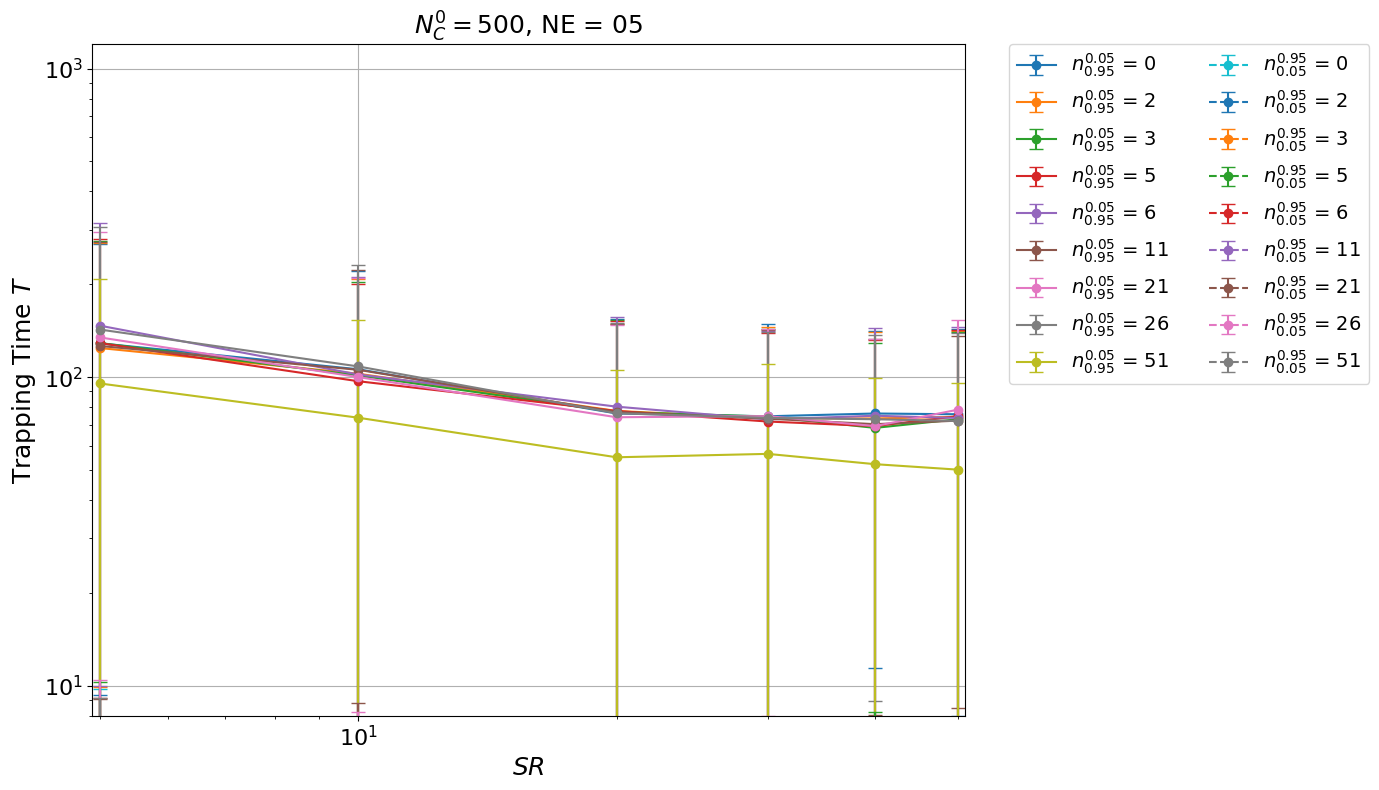

In [46]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 05", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_5_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 10.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


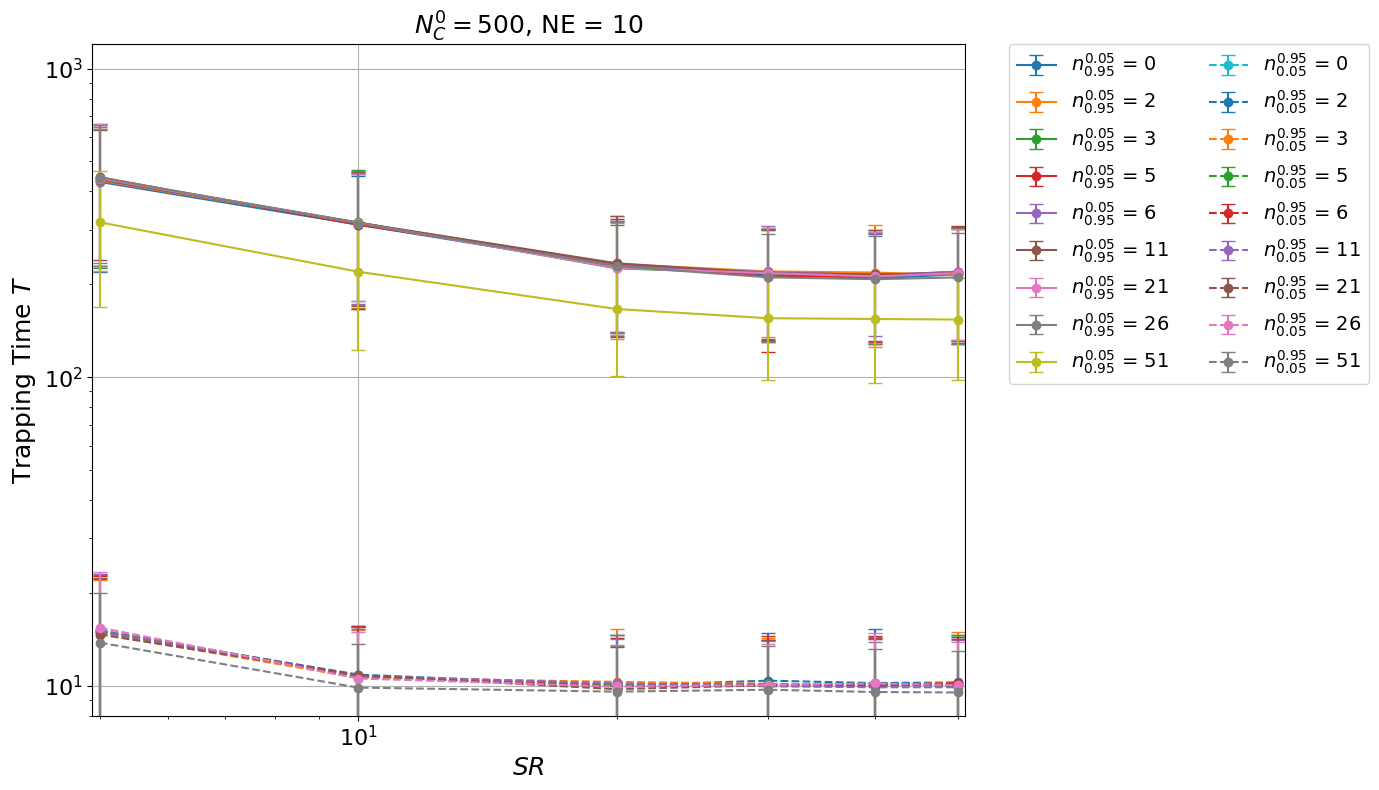

In [47]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP10_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP10_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP10_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP10_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP10_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP10_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP10_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP10_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP10_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP10_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP10_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP10_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP10_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP10_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP10_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 10", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_10_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 20.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


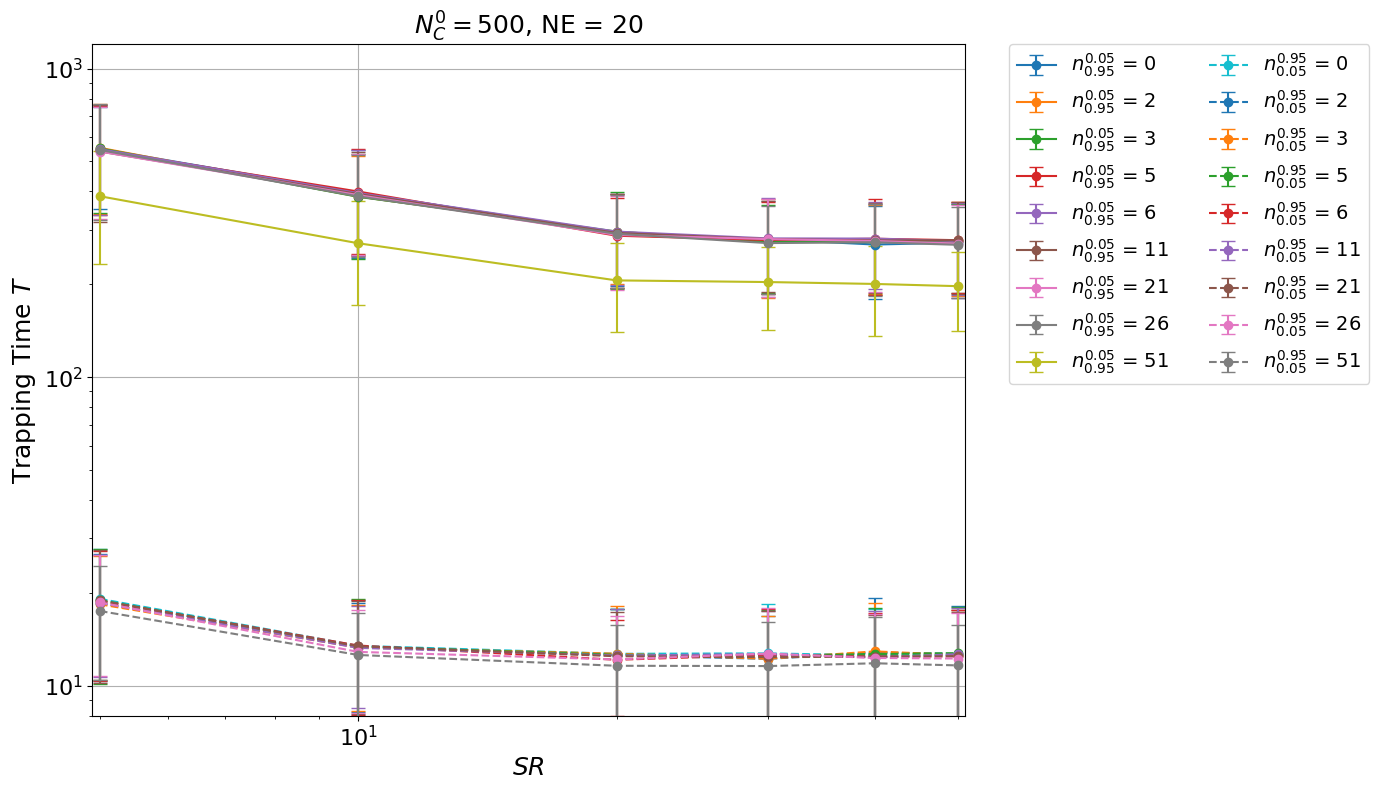

In [48]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP20_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP20_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP20_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP20_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP20_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP20_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP20_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP20_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 20", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_20_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 30.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


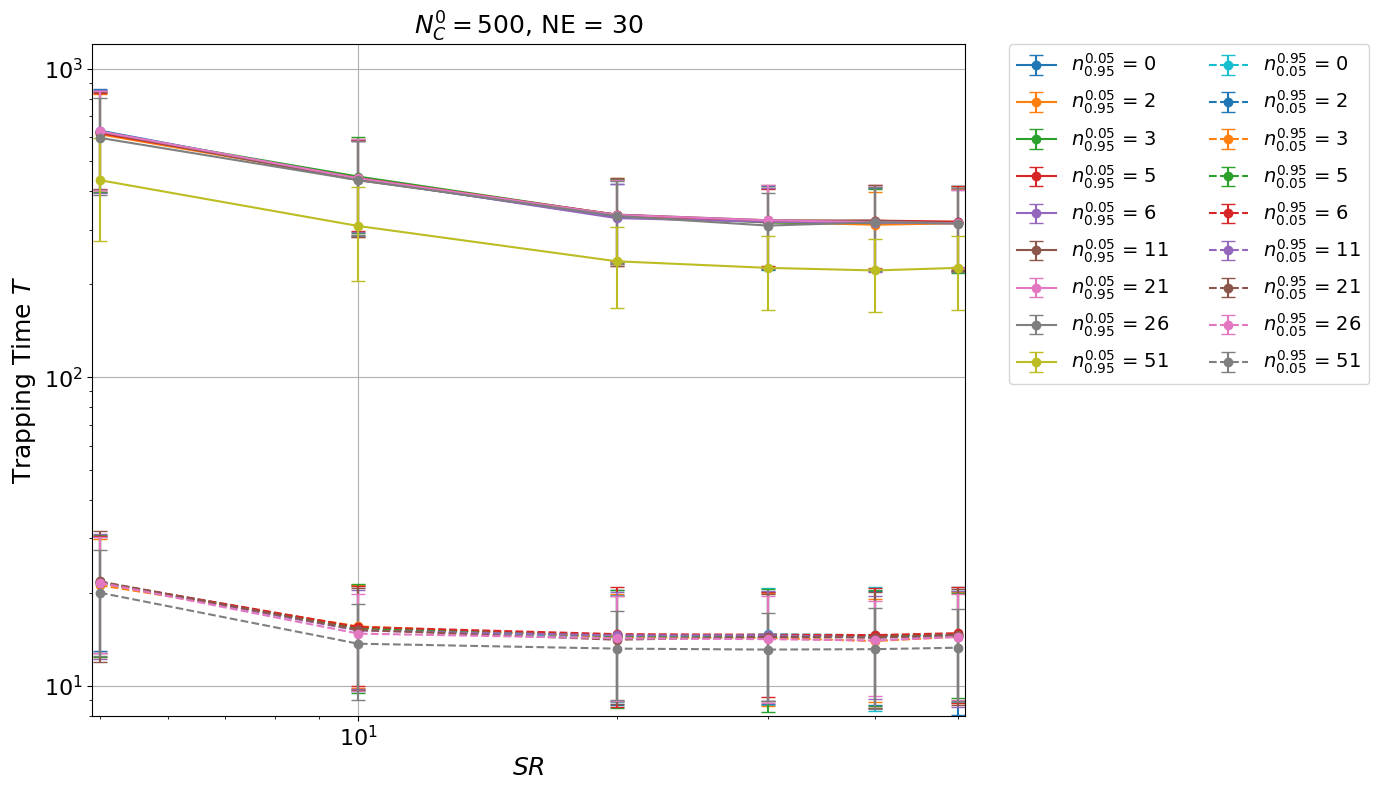

In [49]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 30", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_30_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 40.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


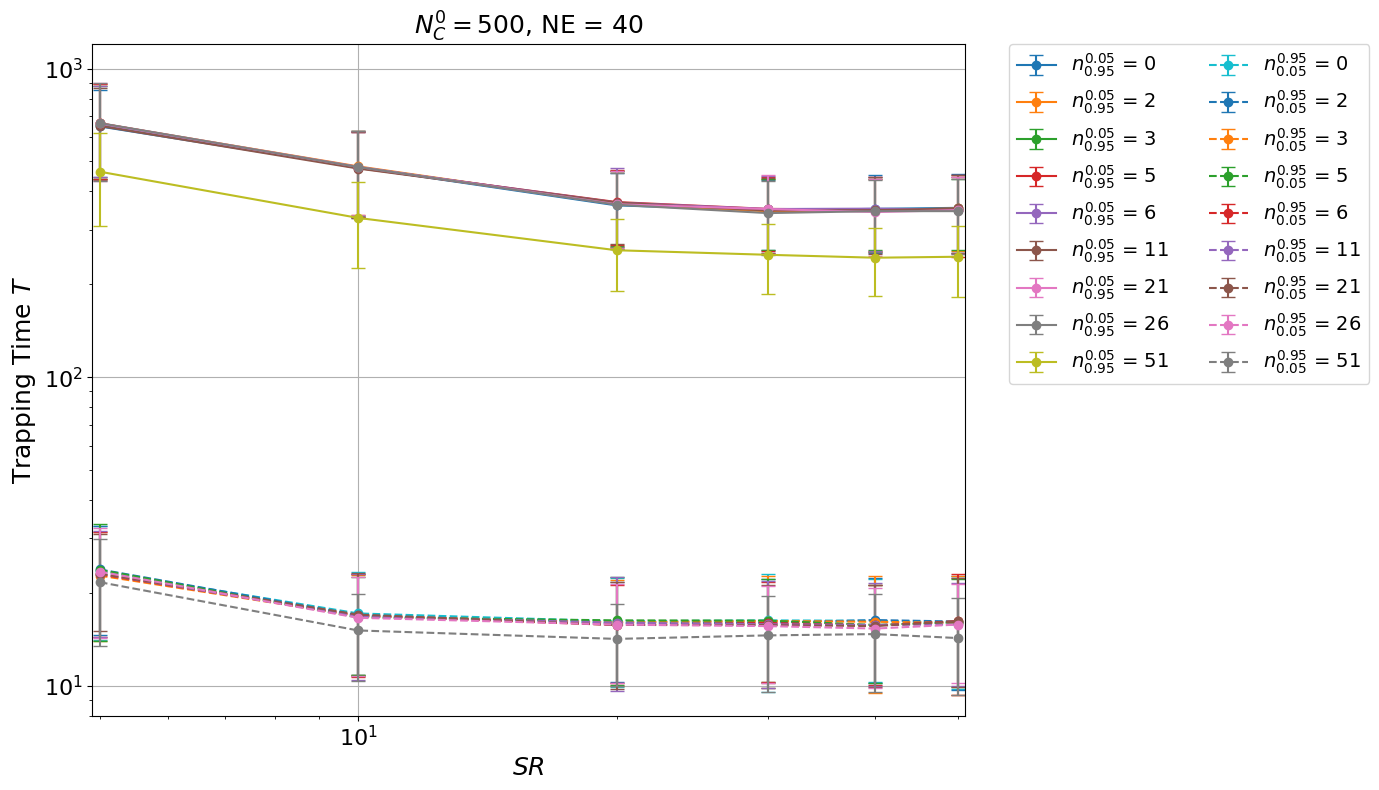

In [50]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP40_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP40_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP40_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP40_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP40_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP40_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP40_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP40_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP40_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP40_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP40_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP40_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP40_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP40_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP40_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 40", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_40_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 50.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


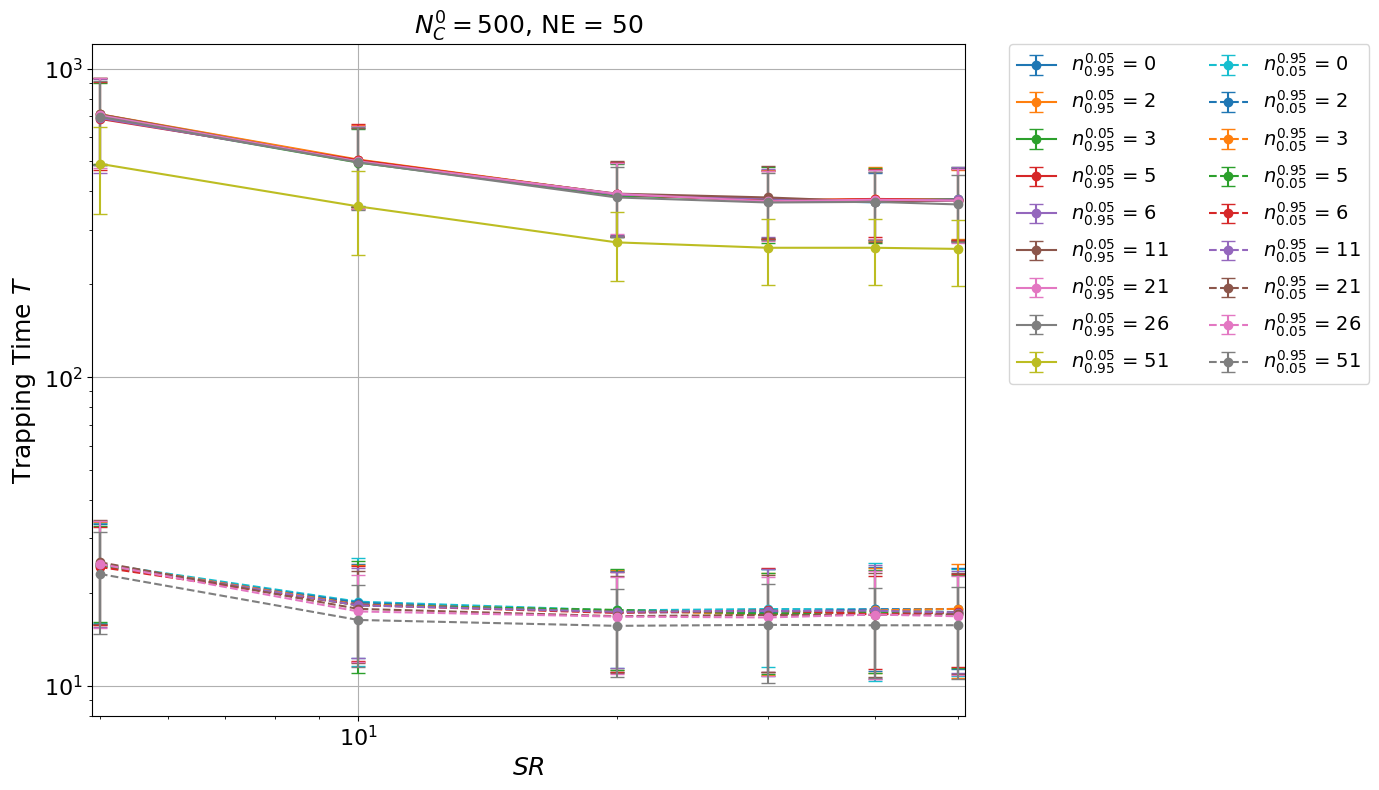

In [51]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 50", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_50_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 60.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


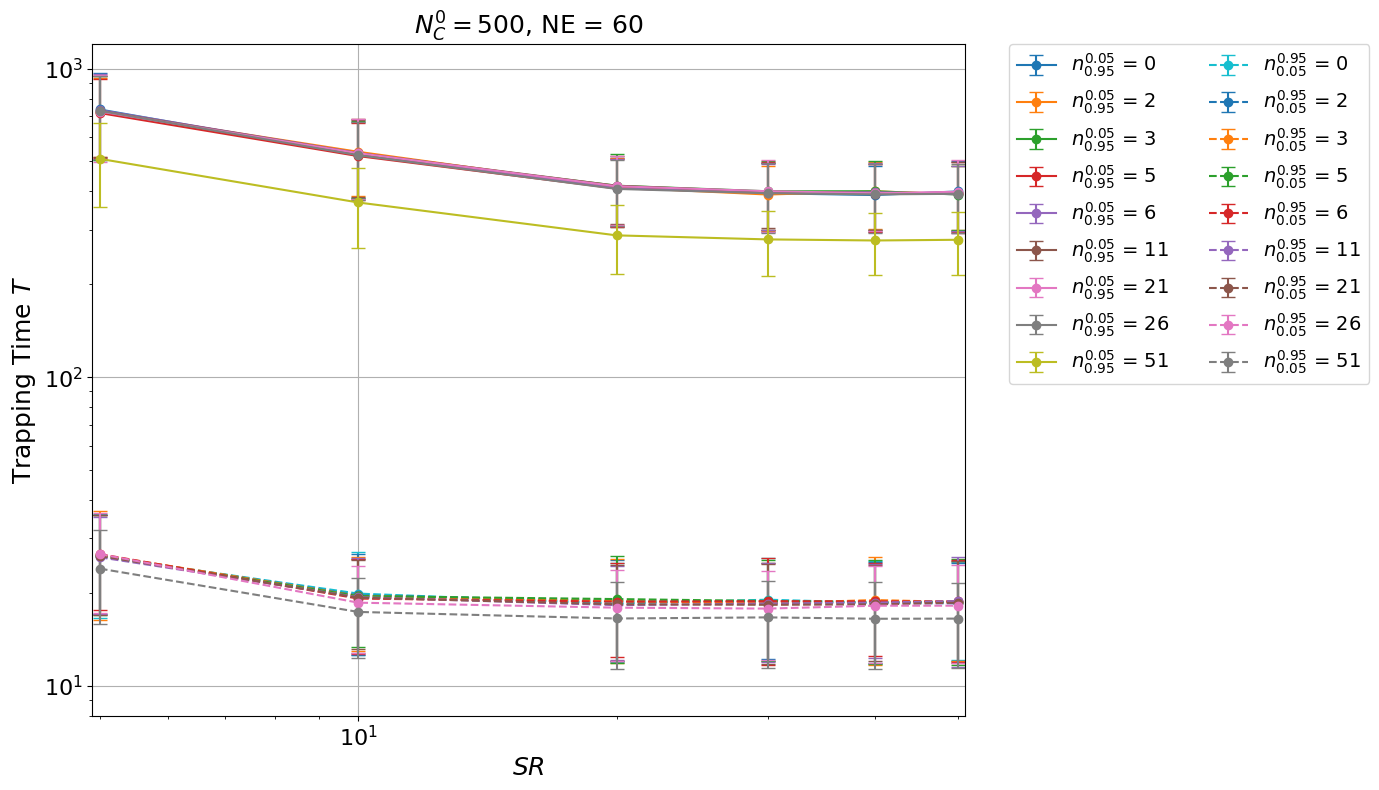

In [52]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 60", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_60_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 70.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


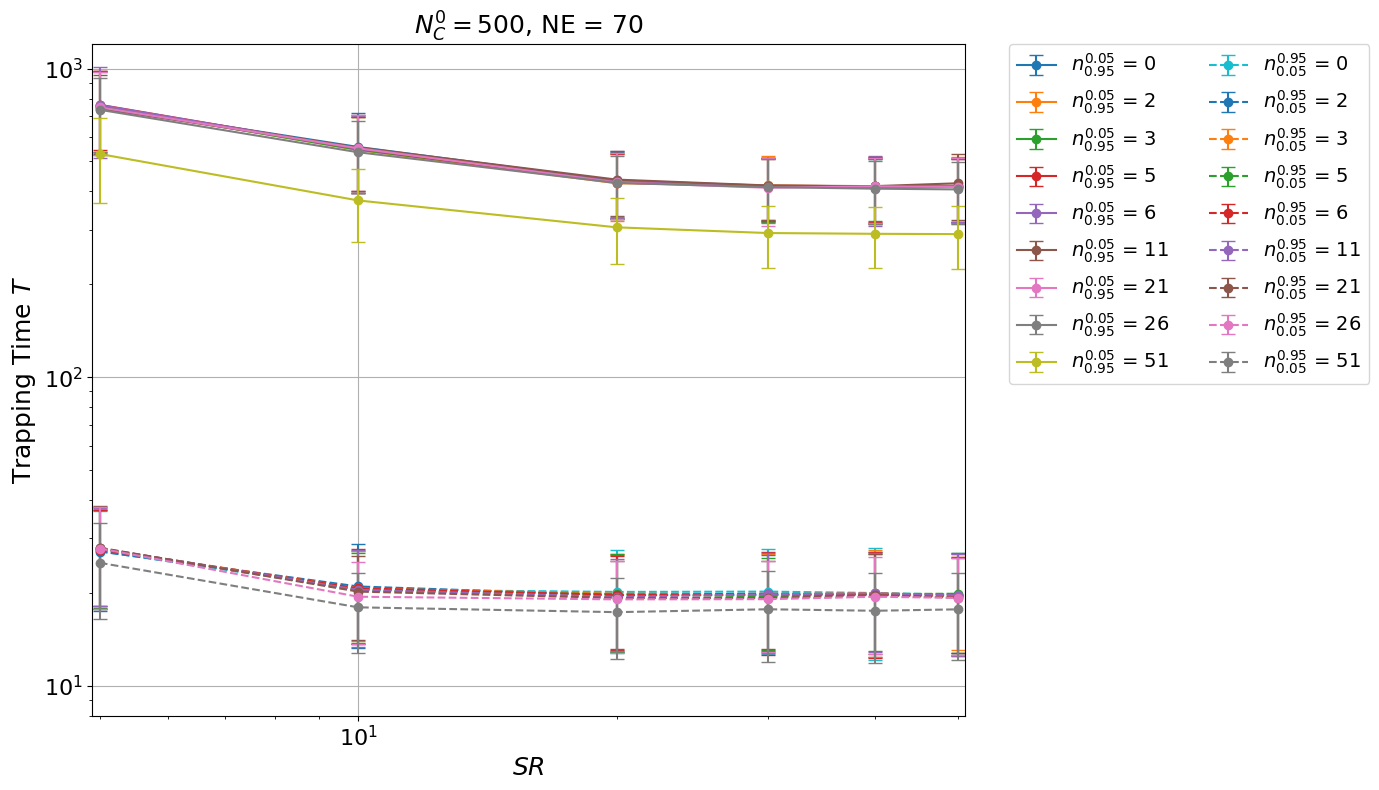

In [53]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 70", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_70_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 80.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


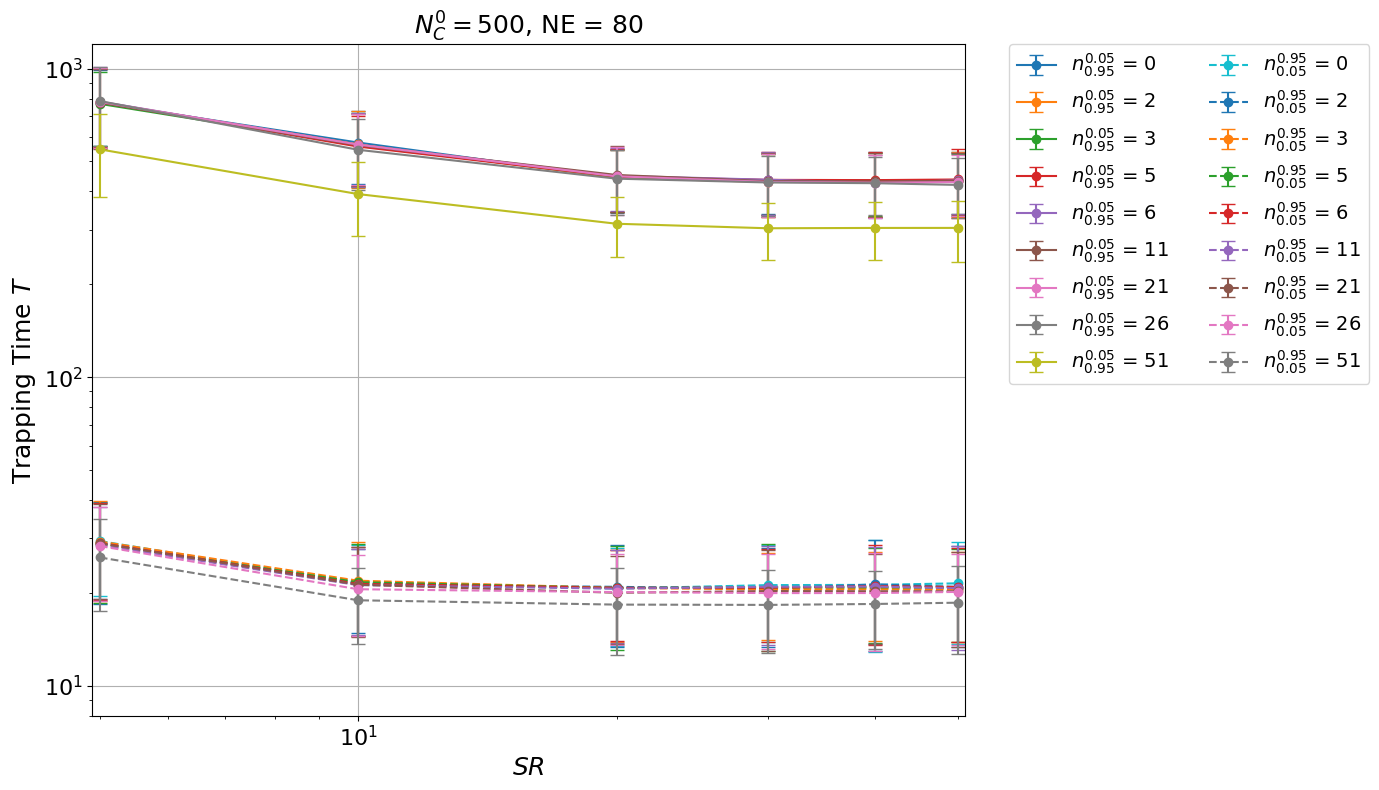

In [54]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 80", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_80_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 90.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


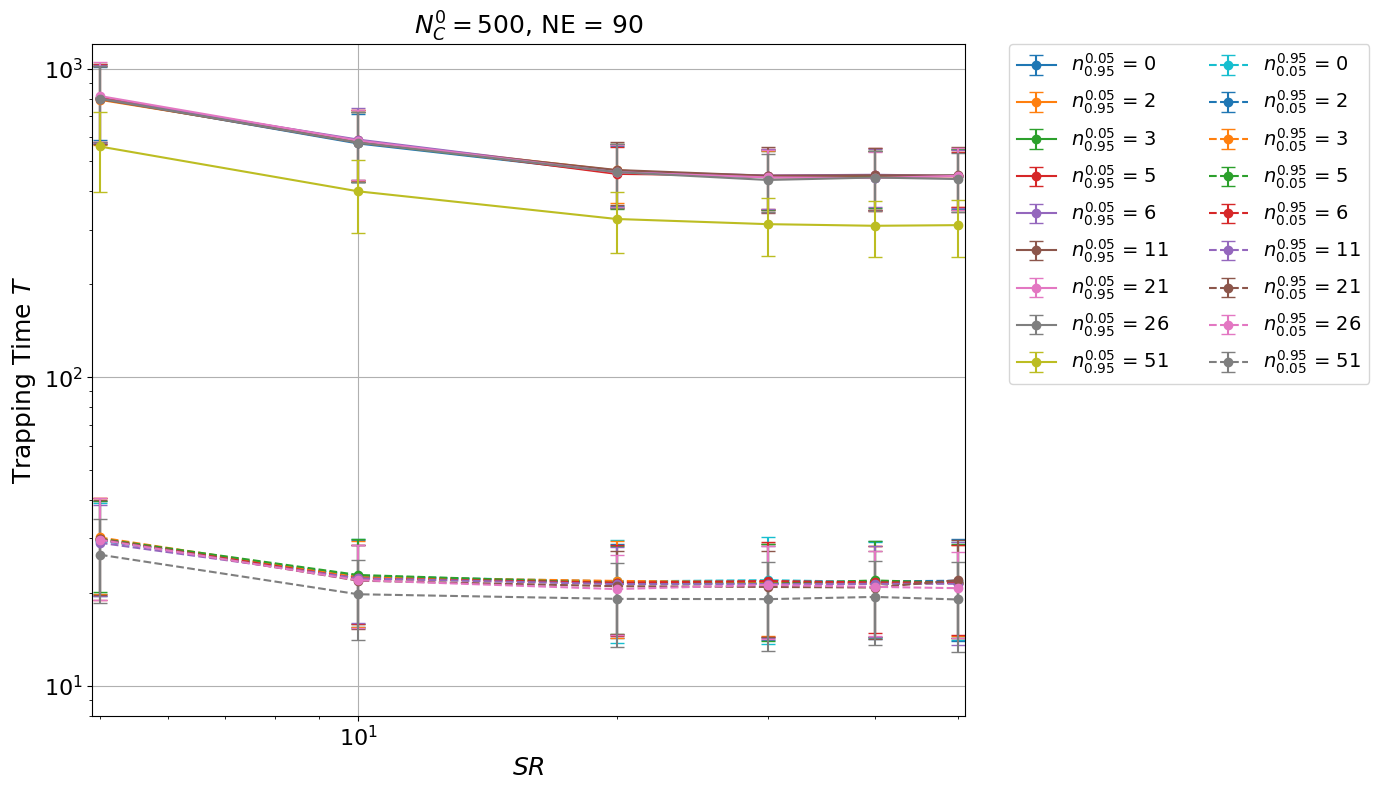

In [55]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 90", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_90_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 100.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


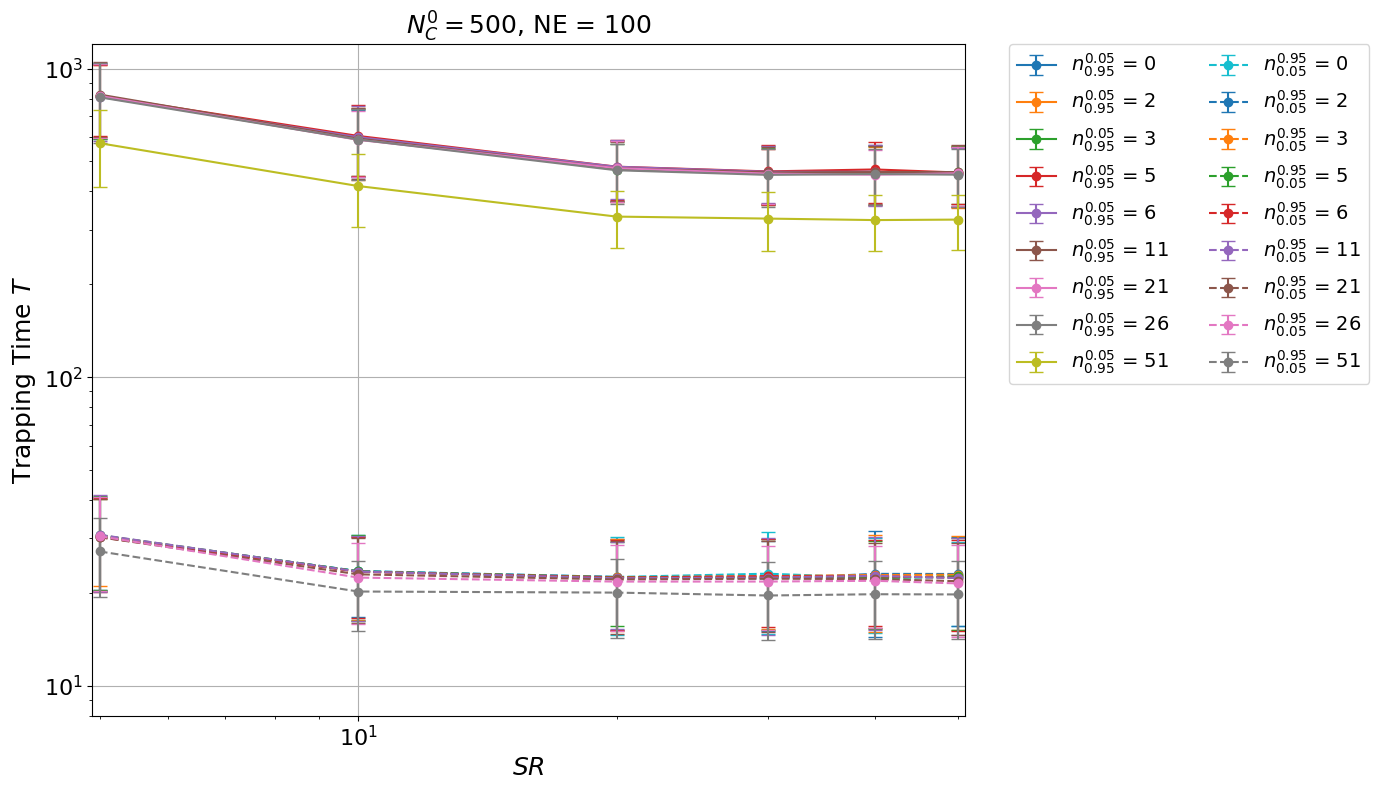

In [56]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 100", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_100_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 500.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


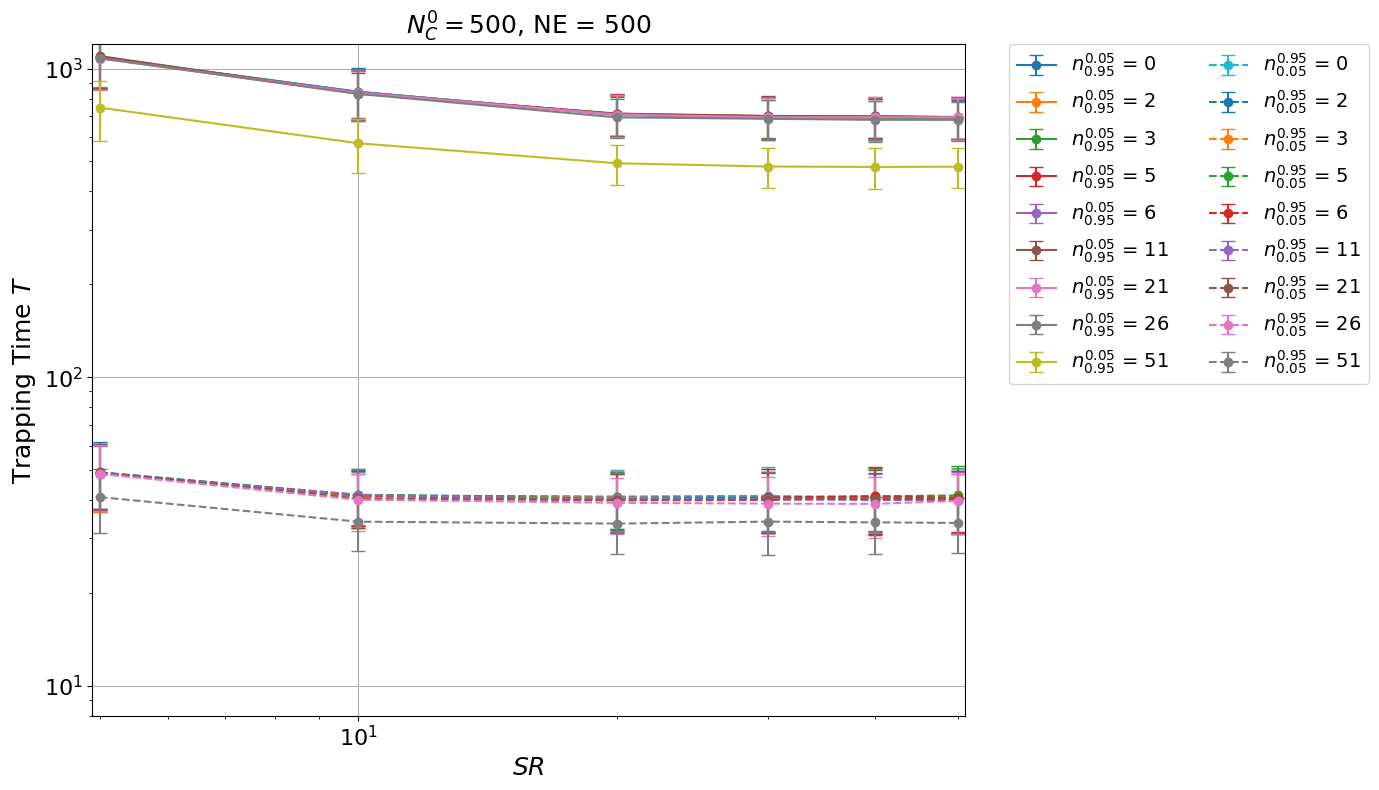

In [57]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 500", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_500_O_v.png",
    num_solid_lines=9)

### TCC = 0.95 TCT = 0.05. e TCC = 0.05 TCT = 0.95
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 1000.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


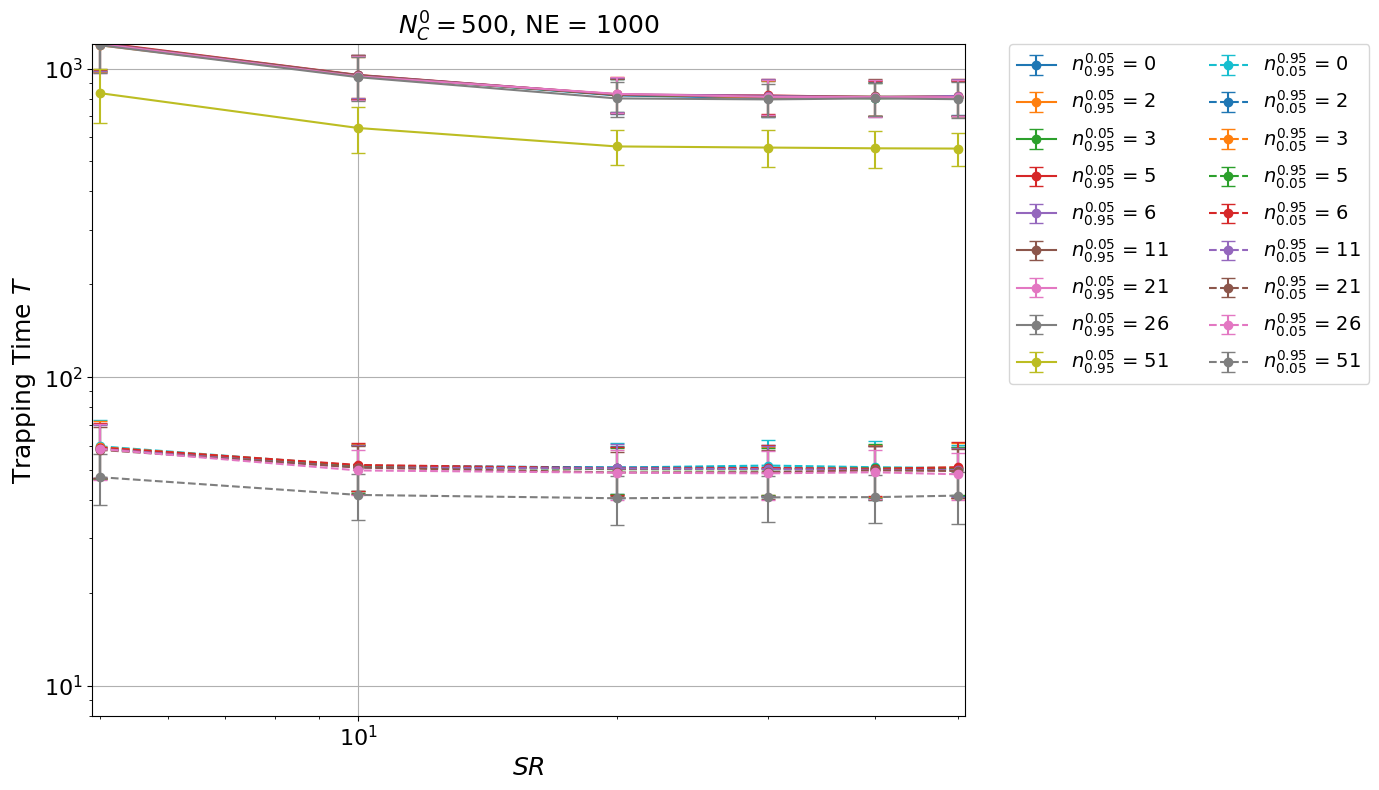

In [58]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50
    ],    
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5",
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11", "$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51",
        #Para o caso 0.95
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5", 
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11","$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 1000", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_095_005_TCT_005_095_NE_1000_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 1.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


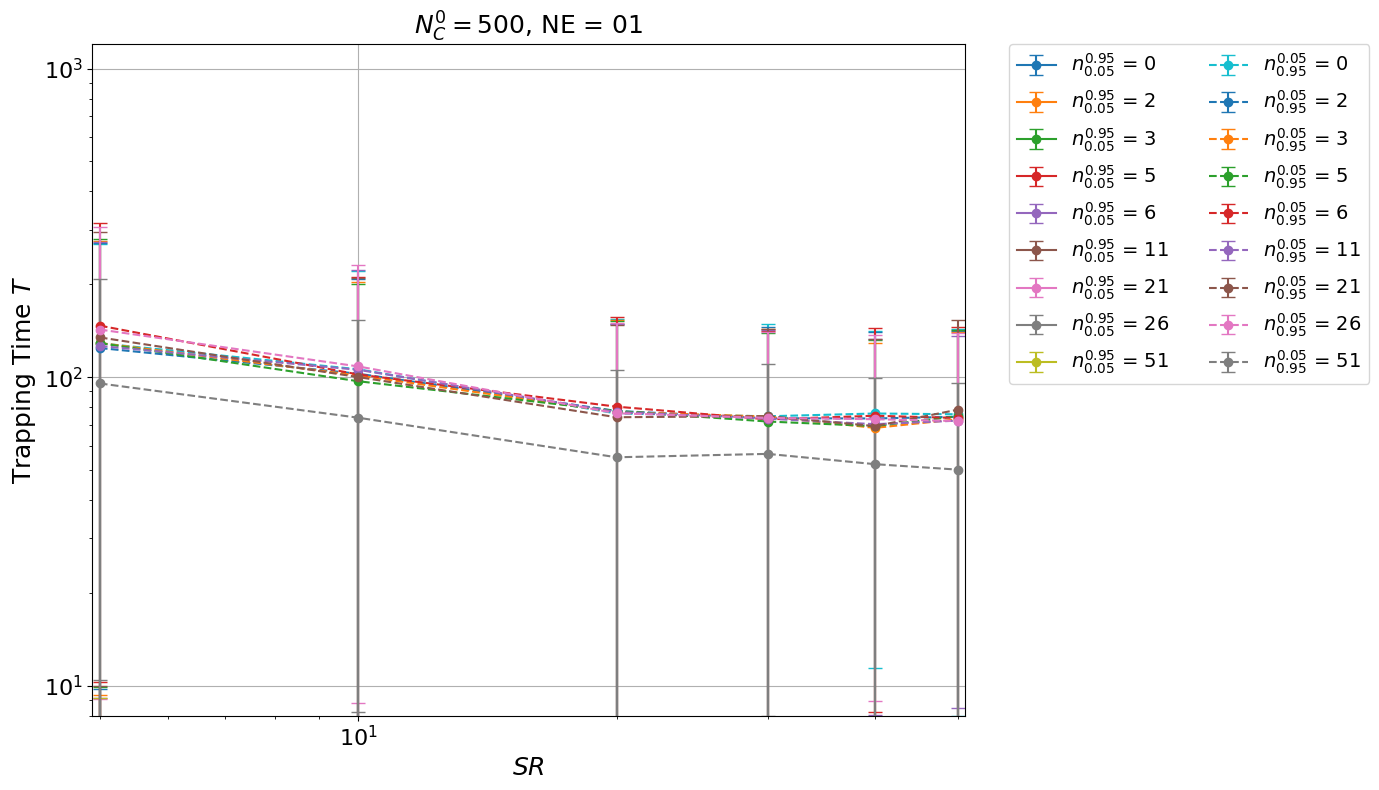

In [59]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP01_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP01_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 01", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_1_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 2.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


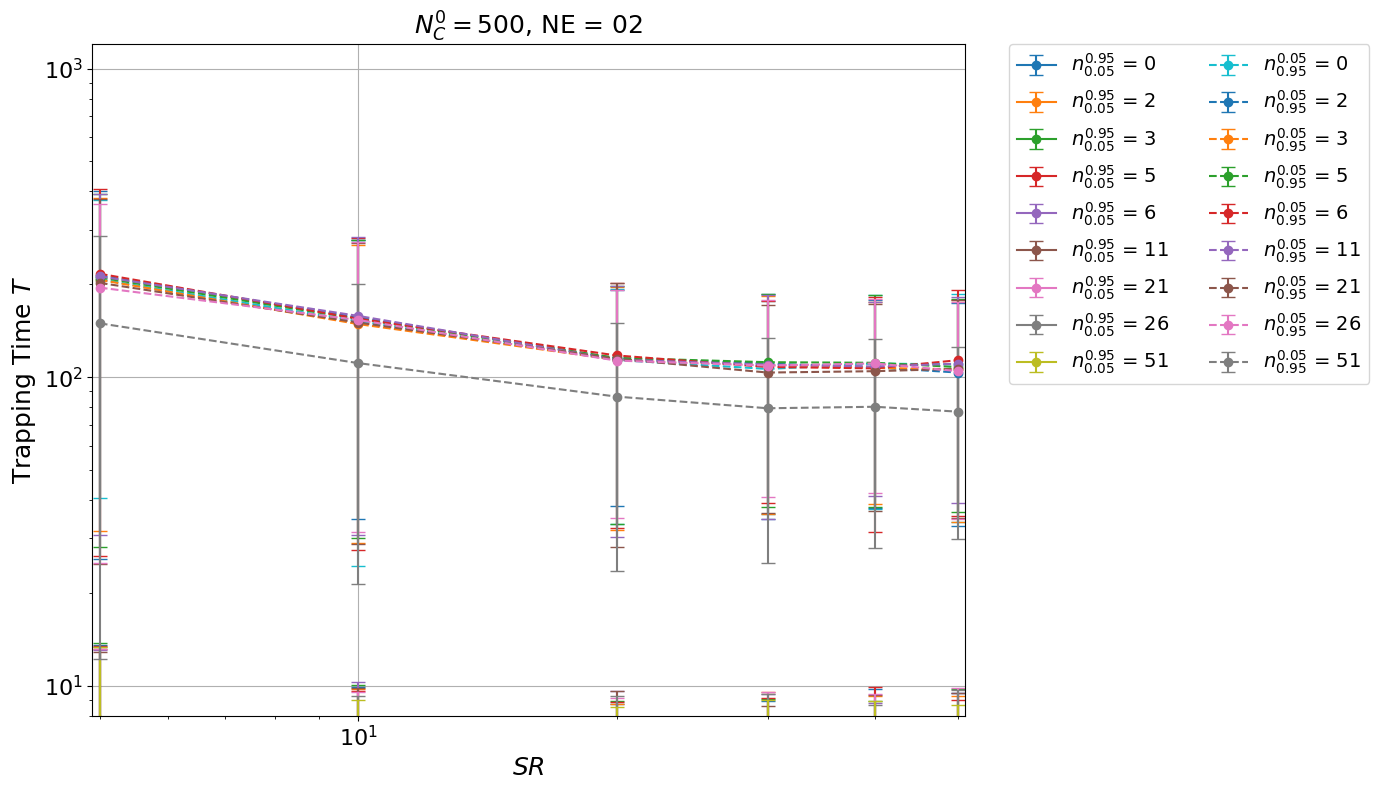

In [60]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP02_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP02_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 02", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_2_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 5.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


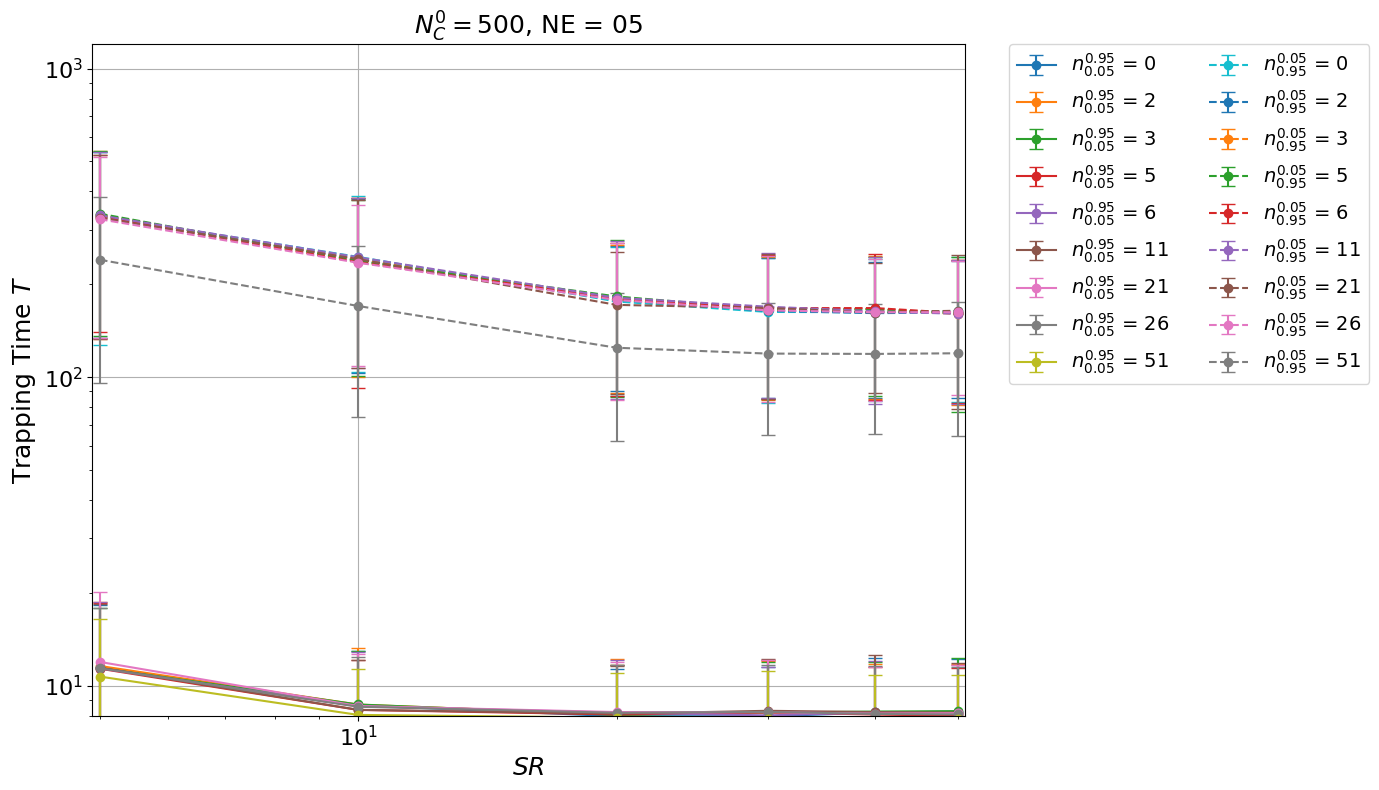

In [61]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP05_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP05_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP05_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP05_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP05_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP05_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP05_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP05_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP05_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP05_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP05_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP05_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP05_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP05_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP05_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP05_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP05_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 05", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_5_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 10.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


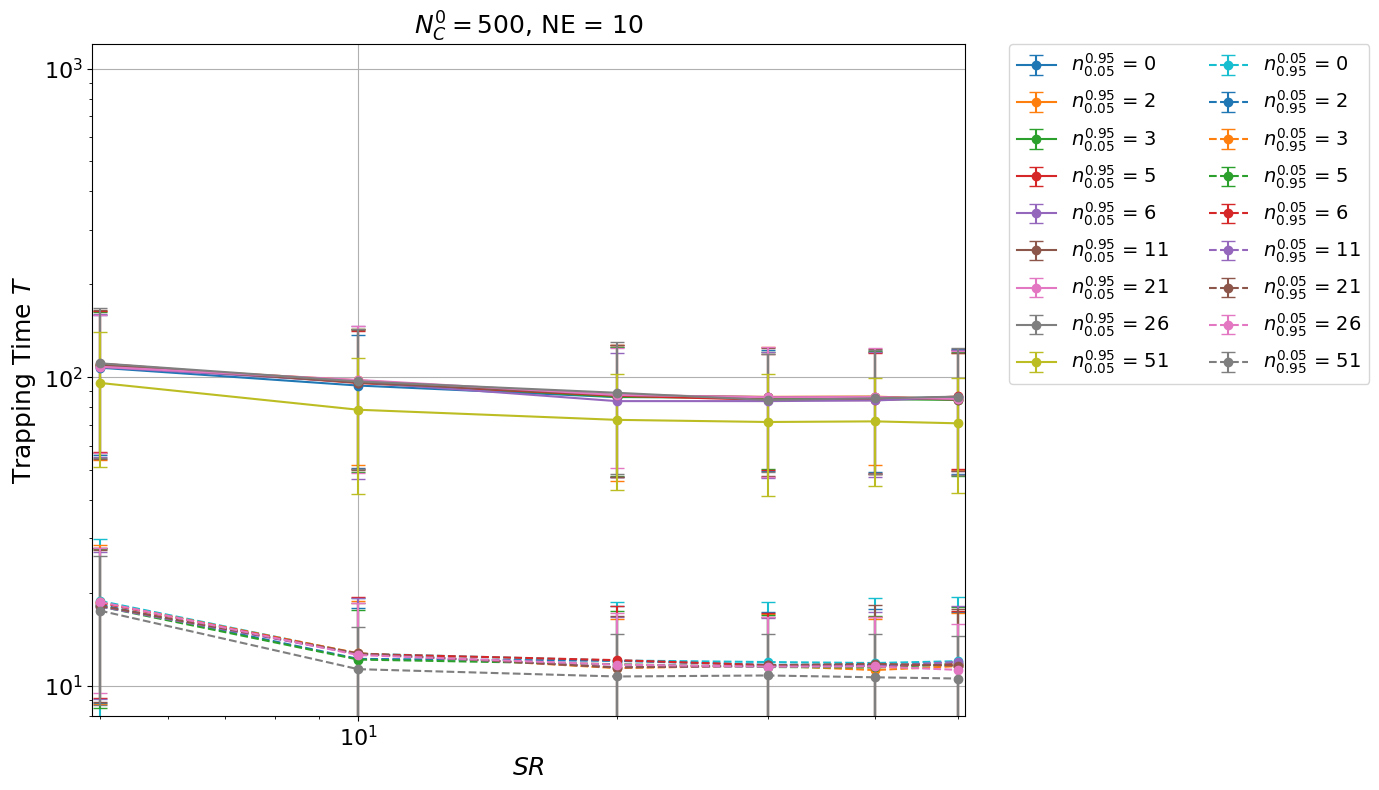

In [62]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP10_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    [
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP10_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 10", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_10_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 20.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


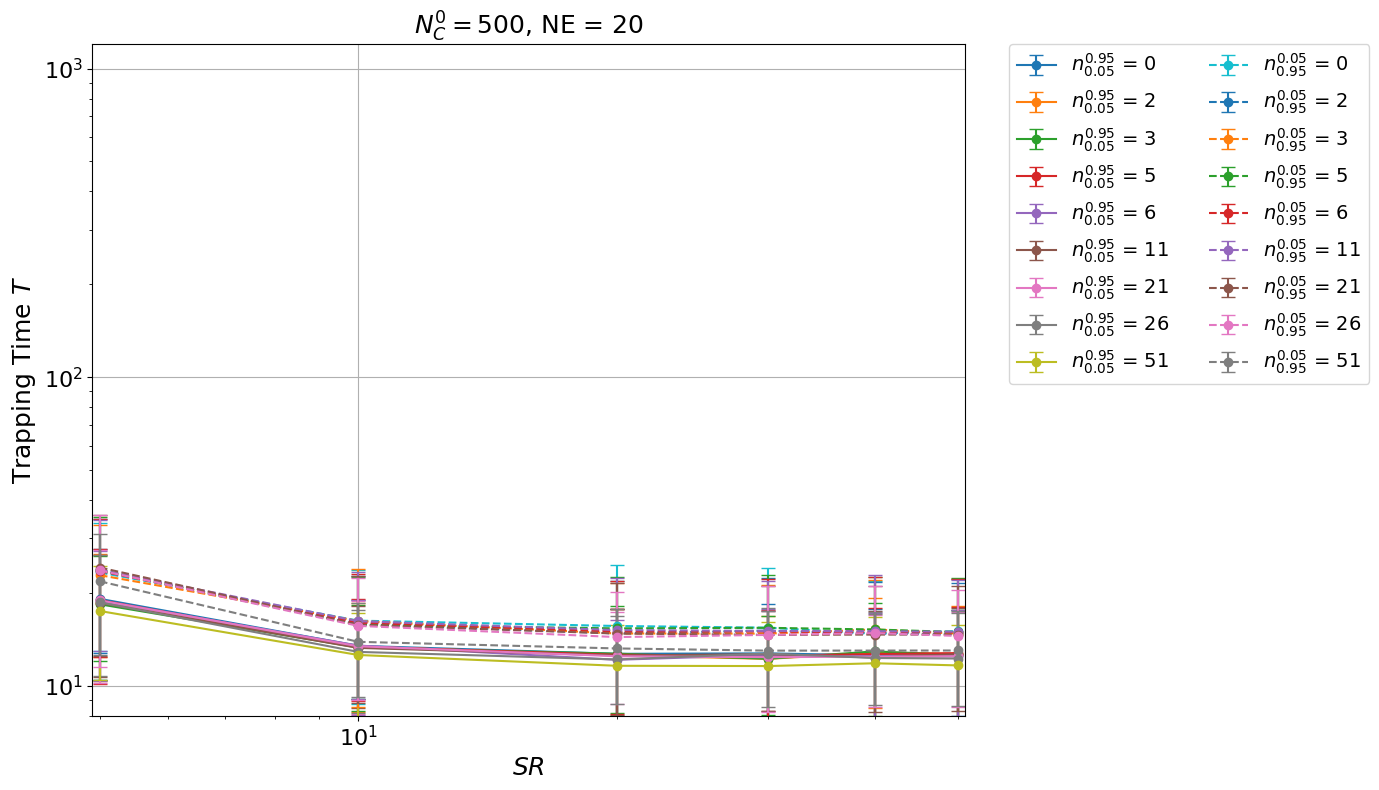

In [63]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP20_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    [
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP20_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 20", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_20_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 30.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


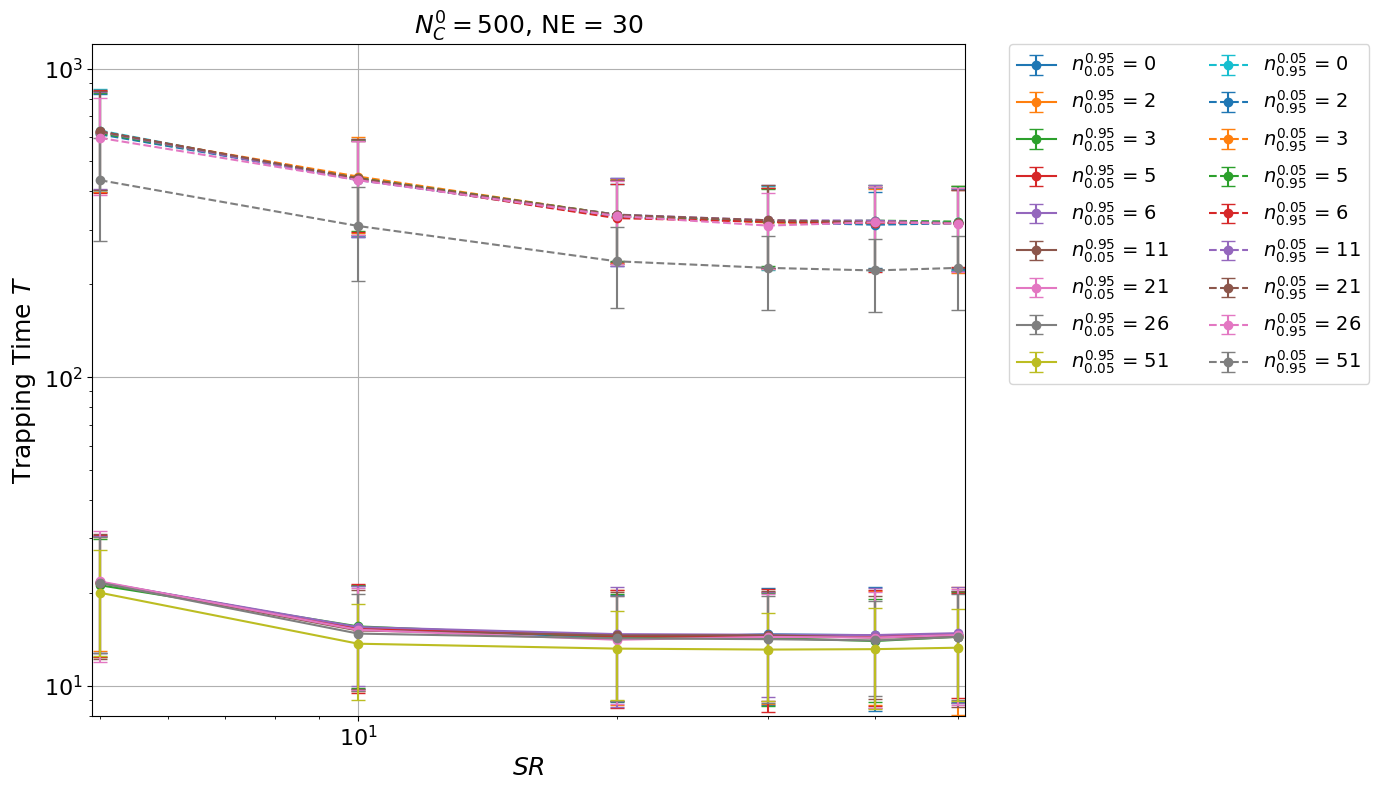

In [64]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP30_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP30_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 30", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_30_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 40.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


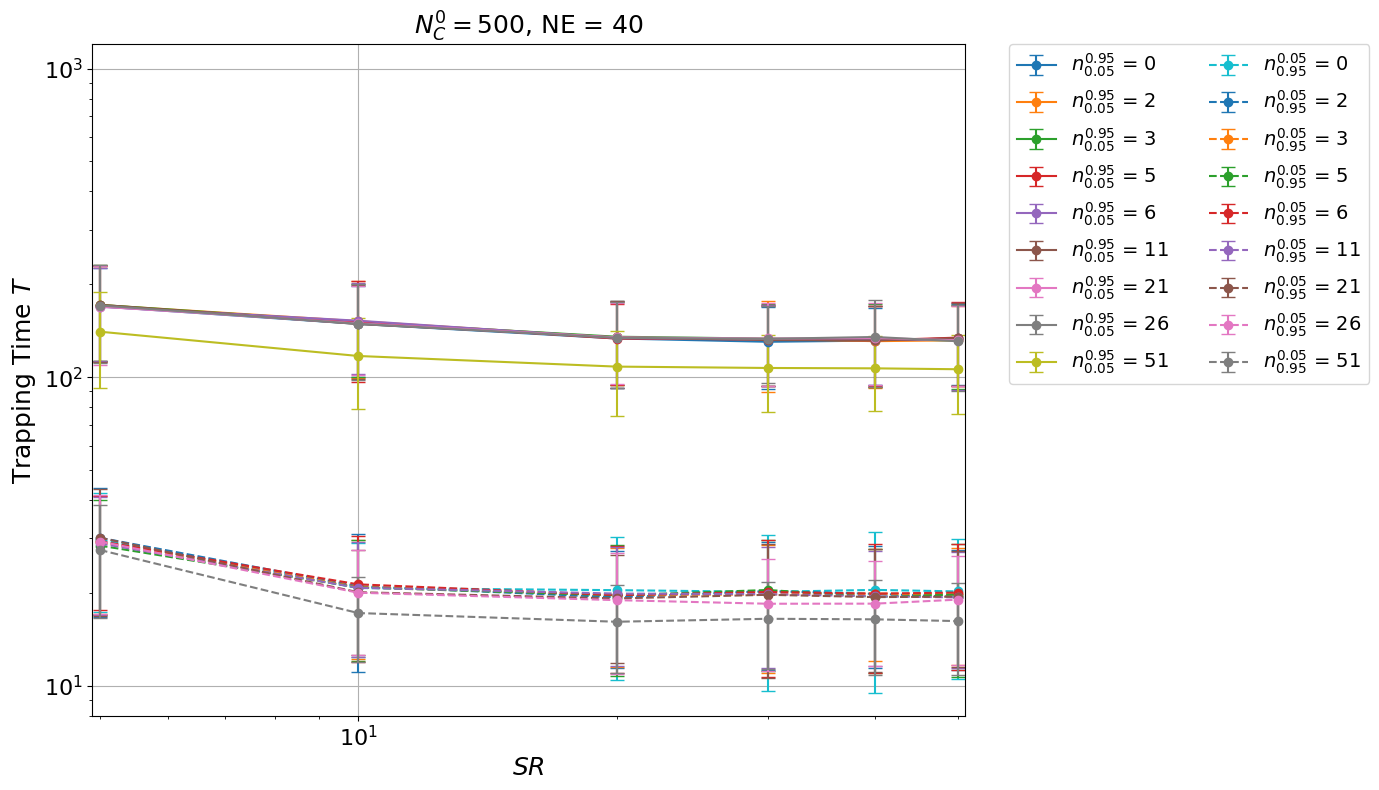

In [65]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_00_SR50
    ],     
    [
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_02_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_03_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_05_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_06_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_11_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_21_SR50
    ],    
    [
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_26_SR50
    ],
    [
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR05, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR10, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR20, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR30,
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR40, 
    df_NP40_NH500_TCC_005_TCT_005_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_00_SR50
    ],     
    [
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_02_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_03_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_05_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_06_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_11_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_21_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_26_SR50
    ],
    [
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR05, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR10, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR20, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR30,
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR40, 
    df_NP40_NH500_TCC_095_TCT_095_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 40", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_40_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 50.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


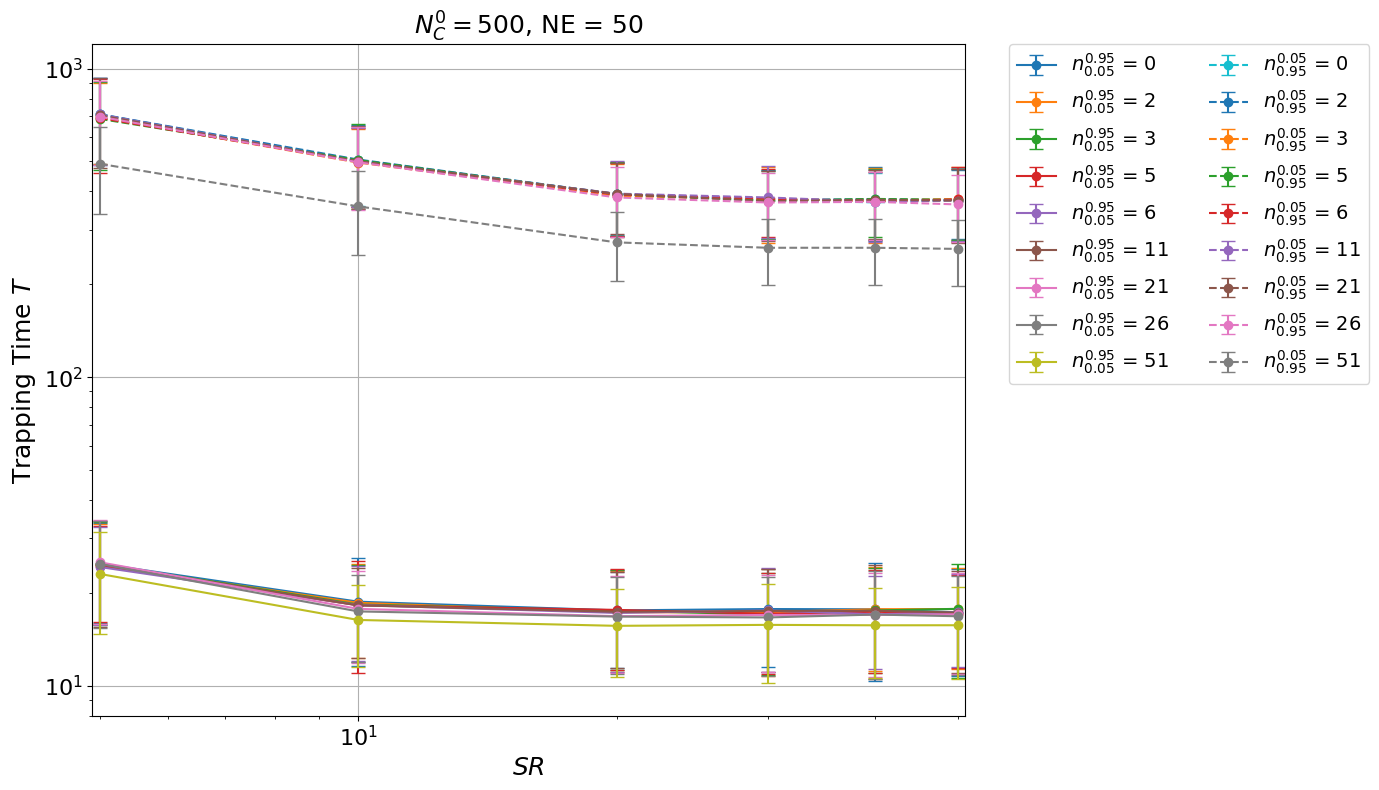

In [66]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP50_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP50_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 50", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_50_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 60.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


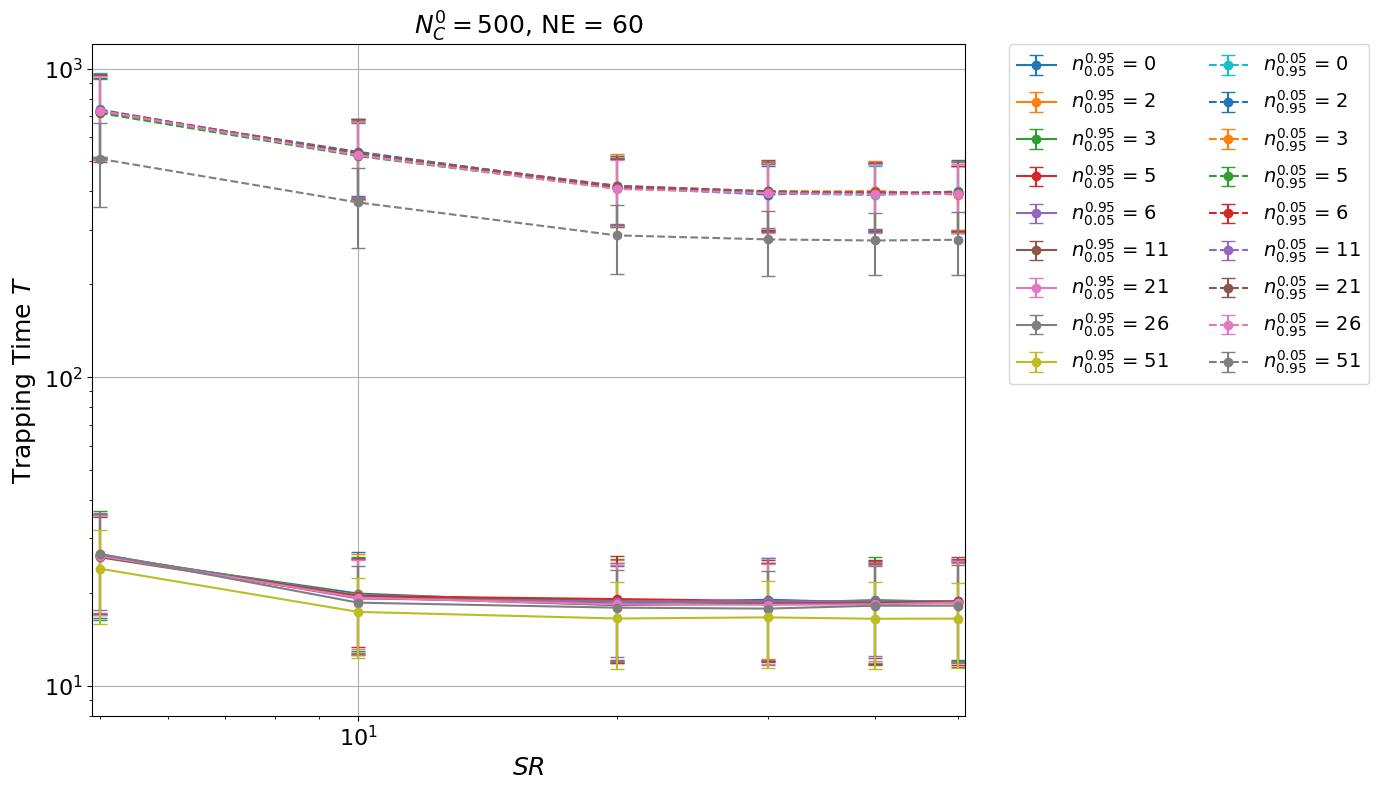

In [67]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP60_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP60_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 60", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_60_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 70.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


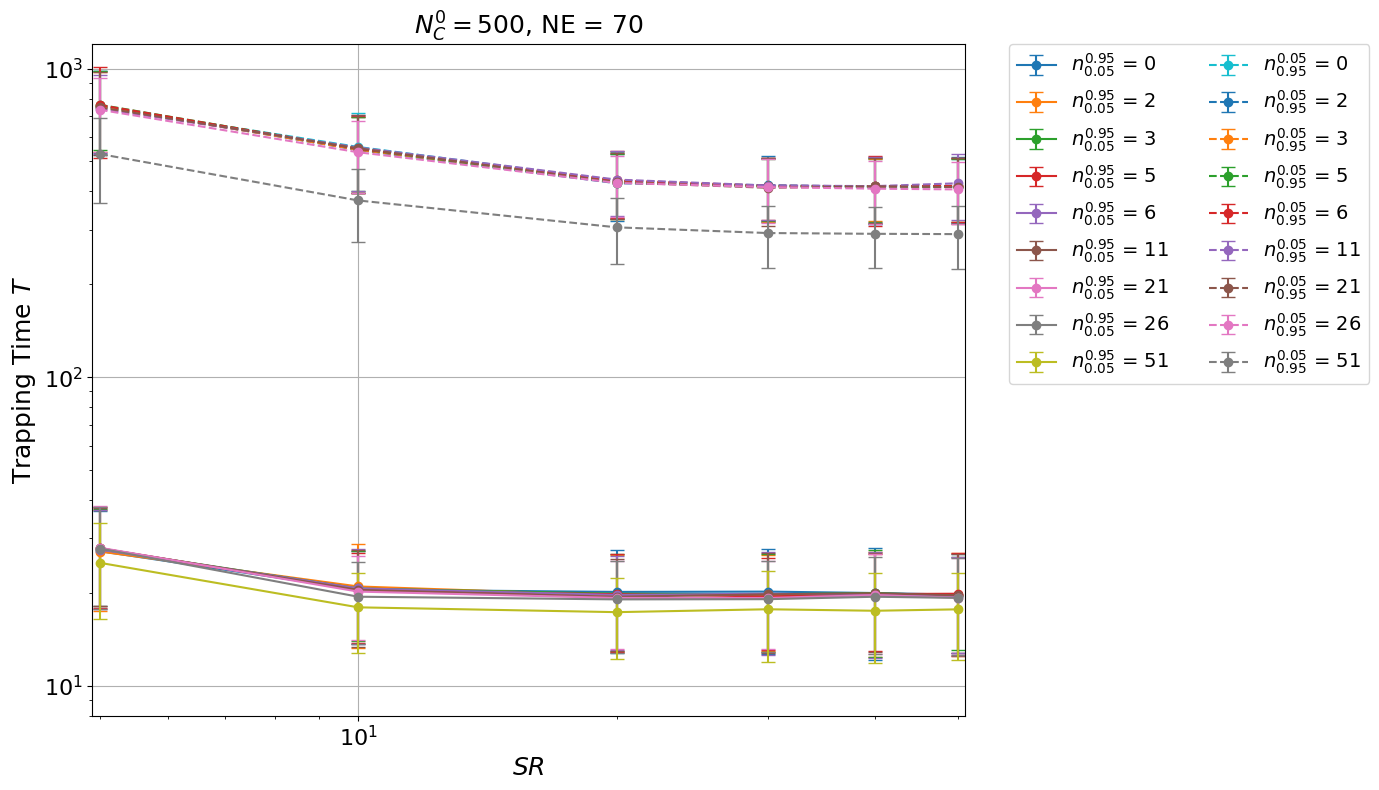

In [68]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP70_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP70_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 70", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_70_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 80.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


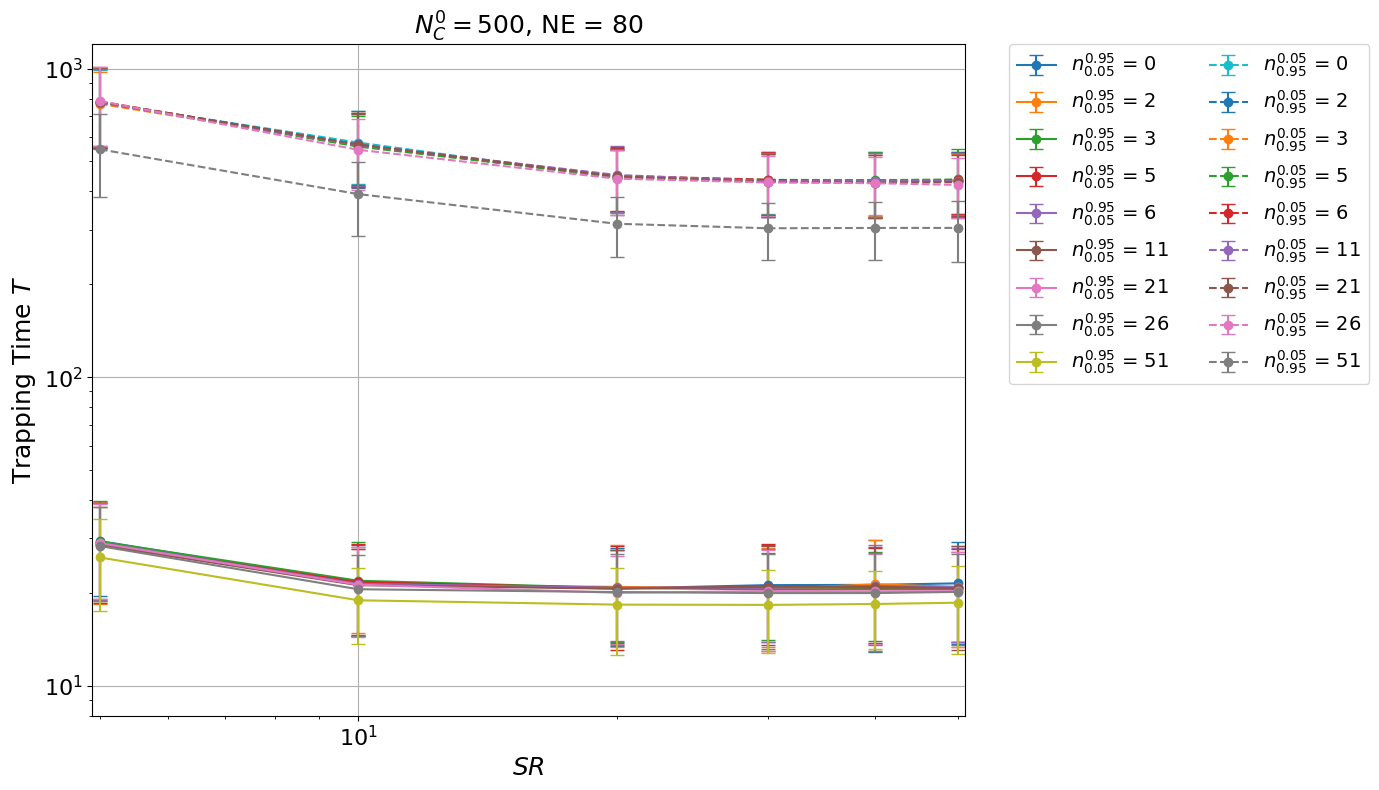

In [69]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP80_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP80_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 80", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_80_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 90.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


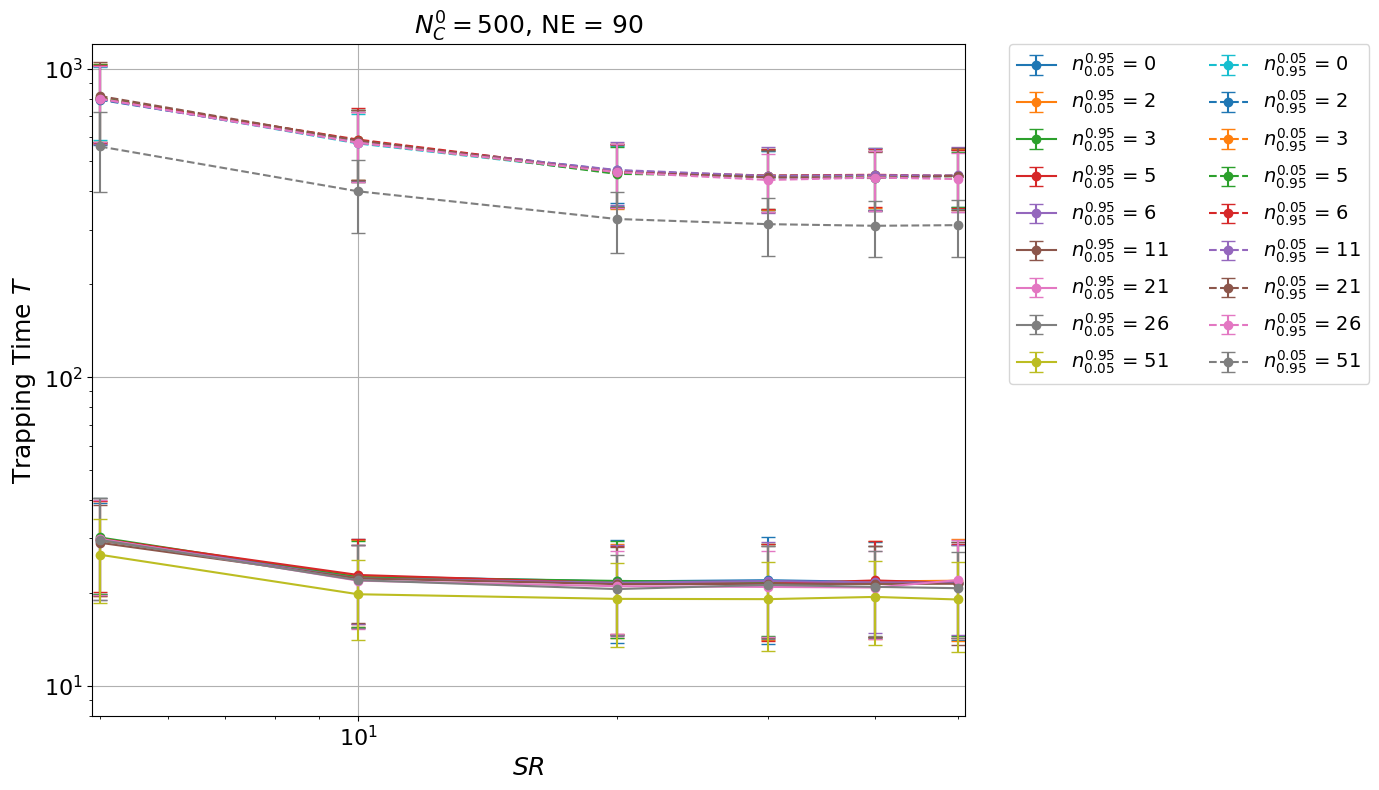

In [70]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP90_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP90_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 90", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_90_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 100.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


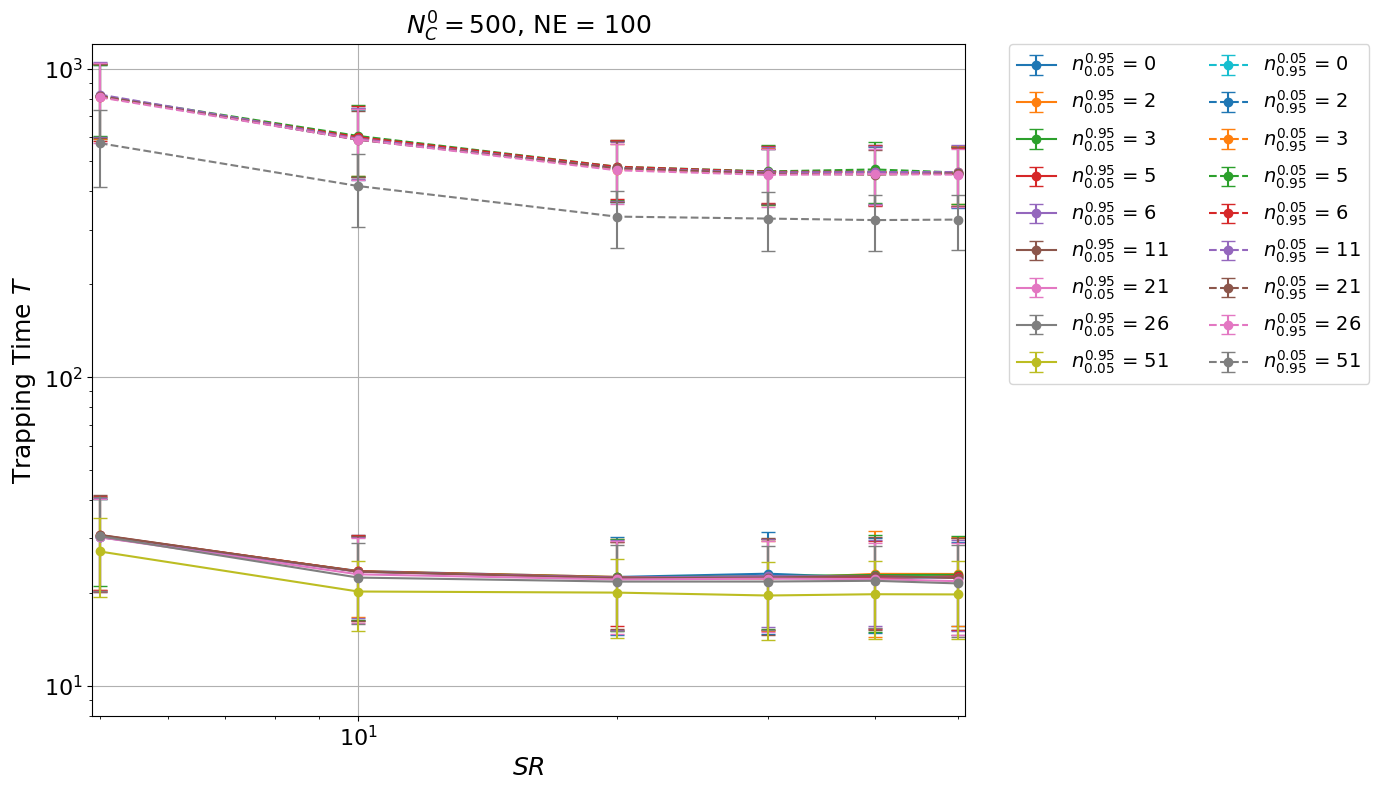

In [71]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP100_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP100_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 100", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_100_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 500.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


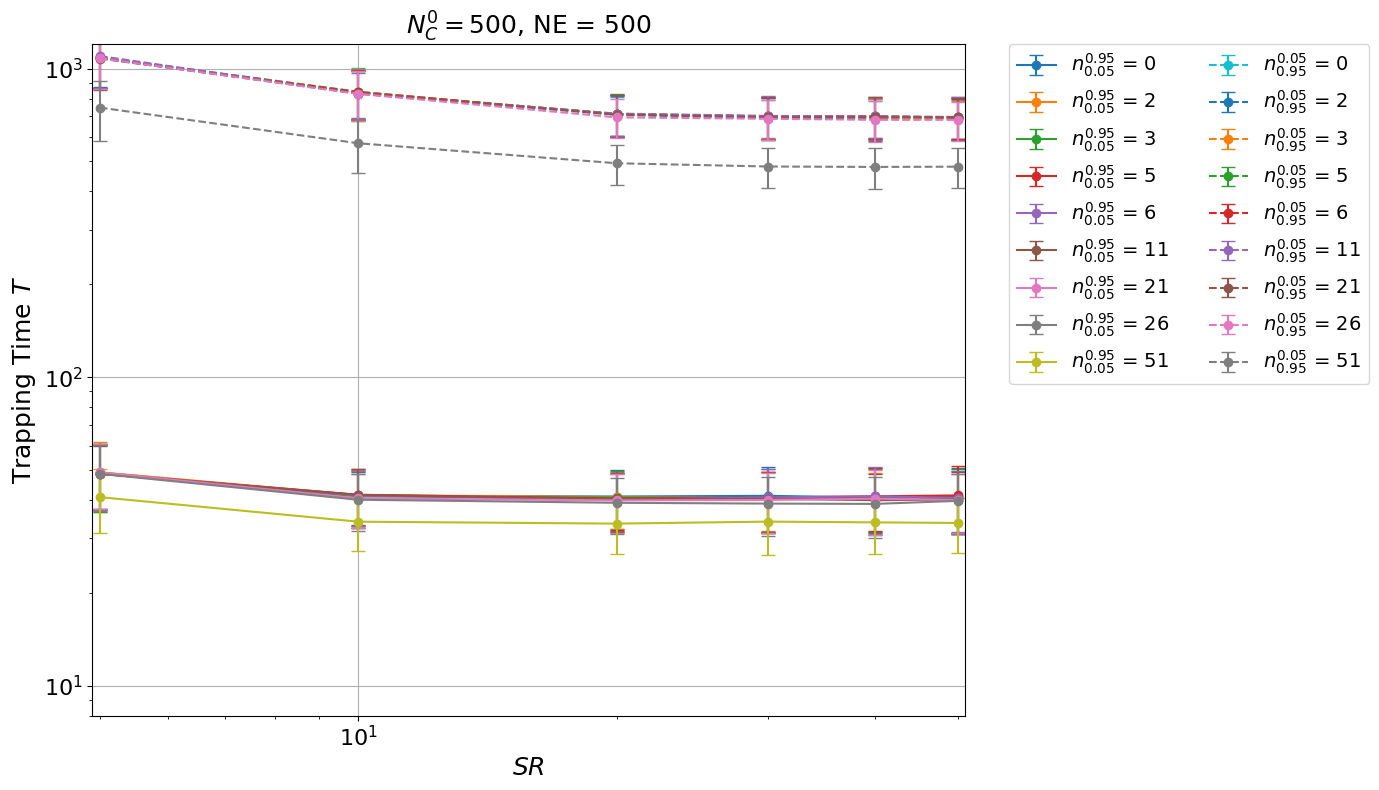

In [72]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP500_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP500_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 500", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_500_O_v.png",
    num_solid_lines=9)

### TCC = 0.05 TCT = 0.95. e TCC = 0.95 TCT = 0.05
- Variando raio de procura.
- Obstáculos = 0, 2, 5, 6, 11, 21, 26, 51.
- NH = 500.
- NP = 1000.
- Tempo de captura individual.

/tmp/ipykernel_35046/3223485003.py:52: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(nc_vals, means, yerr=std_devs, label=label, fmt='-o', capsize=5, linestyle=line_style)


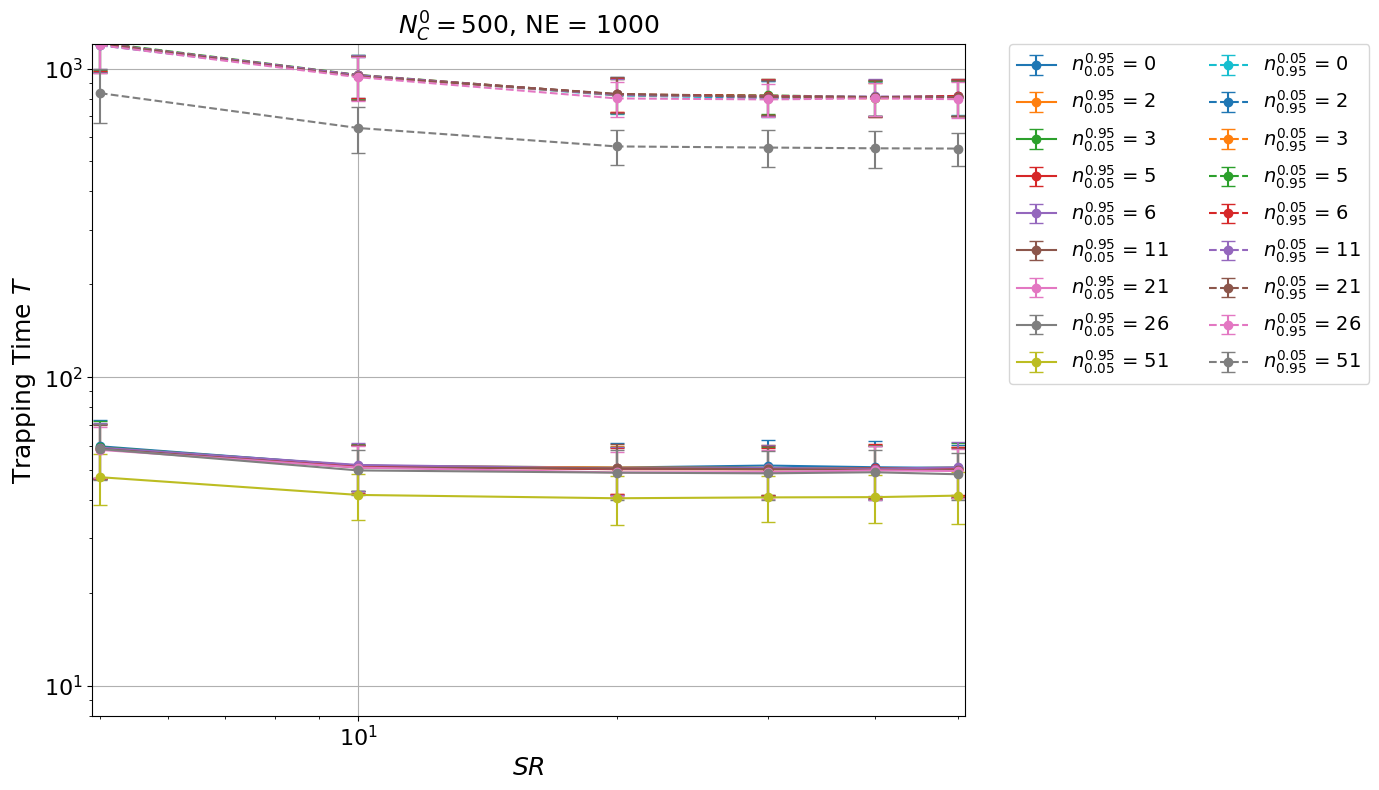

In [73]:
dfs_list = [   
    #Para o caso 0.05 
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_00_SR50
    ],     
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_02_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_03_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_05_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_06_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_11_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_21_SR50
    ],    
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_26_SR50
    ],
    [
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR05, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR10, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR20, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR30,
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR40, 
    df_NP1000_NH500_TCC_005_TCT_095_O_51_SR50
    ],    
    #Para o caso 0.95 
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_00_SR50
    ],     
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_02_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_03_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_05_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_06_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_11_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_21_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_26_SR50
    ],
    [
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR05, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR10, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR20, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR30,
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR40, 
    df_NP1000_NH500_TCC_095_TCT_005_O_51_SR50
    ]
      ]


nc_values = [
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    #Para o caso 0.95
    [5,10,20,30,40,50],  # Valores de NC para O = 0.0
    [5,10,20,30,40,50],  # Valores de NC para O = 0.1
    [5,10,20,30,40,50],   # Valores de NC para O = 0.2
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50],
    [5,10,20,30,40,50]
    ]

labels =[
        #Para o caso 0.05
        "$n_{0.05}^{0.95}$ = 0", "$n_{0.05}^{0.95}$ = 2", "$n_{0.05}^{0.95}$ = 3", "$n_{0.05}^{0.95}$ = 5",
        "$n_{0.05}^{0.95}$ = 6", "$n_{0.05}^{0.95}$ = 11", "$n_{0.05}^{0.95}$ = 21",
        "$n_{0.05}^{0.95}$ = 26","$n_{0.05}^{0.95}$ = 51",
        #Para o caso 0.95
        "$n_{0.95}^{0.05}$ = 0", "$n_{0.95}^{0.05}$ = 2", "$n_{0.95}^{0.05}$ = 3", "$n_{0.95}^{0.05}$ = 5", 
        "$n_{0.95}^{0.05}$ = 6", "$n_{0.95}^{0.05}$ = 11","$n_{0.95}^{0.05}$ = 21",
        "$n_{0.95}^{0.05}$ = 26","$n_{0.95}^{0.05}$ = 51"
        ]

plotar_media_steps_com_erro (
    dfs_list=dfs_list, 
    nc_values=nc_values, 
    labels=labels, 
    title="$N^{0}_{C} = 500$, NE = 1000", 
    xlabel="$SR$", 
    ylabel="Trapping Time $T$", 
    x_log=True, 
    y_log=True, 
    x_min=4.9, x_max=51, 
    y_min=8, y_max=1200, 
    save_path="trap_x_SR_TCC_005_095_TCC_095_005_NE_1000_O_v.png",
    num_solid_lines=9)